<span style='font-size:large'>**Project Overview**</span>

**Overarching Capstone Project Question**

How have urban climate risk assessments, hazard reporting, and adaptation programs changed over the past five years, and did the COVID\-19 pandemic affect these municipal efforts? How do city size, population density, and hazard exposure influence the implementation of climate risk assessments and adaptation programs?

Goals:

1. Track trends in climate risk assessments and hazards across cities 2019–2023.
2. Examine adaptation program implementation by city characteristics.
3. Explore whether the COVID\-19 pandemic influenced these metrics.
4. Analyze how city size, population, and density relate to hazards and adaptations.



Import libraries



In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [4]:
df = pd.read_csv("capstone_city_climate_data.csv")

In [5]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        90 non-null     object 
 1   climate_risk_assessment_YN  90 non-null     object 
 2   CDP_response_year           90 non-null     int64  
 3   num_hazards                 89 non-null     float64
 4   most_common_hazard          89 non-null     object 
 5   population                  18 non-null     float64
 6   population_year             18 non-null     float64
 7   land_area_sqkm              18 non-null     float64
 8   num_adapt_programs          88 non-null     float64
 9   pop_density                 18 non-null     float64
dtypes: float64(6), int64(1), object(3)
memory usage: 7.2+ KB


,CDP_response_year,num_hazards,population,population_year,land_area_sqkm,num_adapt_programs,pop_density
count,90.000000,89.000000,1.800000e+01,18.000000,18.000000,88.000000,18.000000
mean,2021.000000,4.707865,1.836252e+06,2021.444444,782.255556,6.545455,2987.666077
std,1.422136,1.423841,1.910582e+06,0.921777,508.484691,5.132518,2631.828353
min,2019.000000,2.000000,7.132520e+05,2020.000000,121.000000,1.000000,711.715853
25%,2020.000000,4.000000,9.003865e+05,2021.000000,381.500000,4.000000,1251.396830
50%,2021.000000,5.000000,1.292958e+06,2021.500000,678.500000,5.000000,1972.758979
75%,2022.000000,6.000000,1.636839e+06,2022.000000,1137.500000,7.000000,3971.083574
max,2023.000000,9.000000,8.804190e+06,2023.000000,1823.000000,26.000000,11316.439589


In [6]:
# Fill missing population and land area with 2023 values
pop_2023 = df[df['CDP_response_year']==2023][['city', 'population_current', 'land_area']]
df = df.merge(pop_2023, on='city', how='left', suffixes=('', '_2023'))

# Fill missing values
df['population_current'] = df['population_current'].fillna(df['population_current_2023'])
df['land_area'] = df['land_area'].fillna(df['land_area_2023'])

# Compute population density
df['pop_density'] = df['population_current'] / df['land_area']

# Drop temporary columns
df.drop(columns=['population_current_2023','land_area_2023'], inplace=True)


KeyError: "['population_current', 'land_area'] not in index"

In [66]:
# Load all datasets
# Population and land area
pop_2023 = pd.read_csv("2023_population.csv")
land_2023 = pd.read_csv("2023_land_area.csv")

# Climate risk assessments
assess_2019 = pd.read_csv("2019_assessment.csv")
assess_2020 = pd.read_csv("2020_assessment.csv")
assess_2021 = pd.read_csv("2021_assessment.csv")
assess_2022 = pd.read_csv("2022_assessment.csv")
assess_2023 = pd.read_csv("2023_assessment.csv")

# Climate hazards
haz_2019 = pd.read_csv("2019_hazards.csv")
haz_2020 = pd.read_csv("2020_hazards.csv")
haz_2021 = pd.read_csv("2021_hazards.csv")
haz_2022 = pd.read_csv("2022_hazards.csv")
haz_2023 = pd.read_csv("2023_hazards.csv")

# Adaptation programs
adapt_2019 = pd.read_csv("2019_adaptation.csv")
adapt_2020 = pd.read_csv("2020_adaptation.csv")
adapt_2021 = pd.read_csv("2021_adaptation.csv")
adapt_2022 = pd.read_csv("2022_adaptation.csv")
adapt_2023 = pd.read_csv("2023_adaptation.csv")

In [67]:
# Combine assessment datasets
assessment = pd.concat([
    assess_2019,
    assess_2020,
    assess_2021,
    assess_2022,
    assess_2023])

# Combine hazard datasets
hazards = pd.concat([
    haz_2019,
    haz_2020,
    haz_2021,
    haz_2022,
    haz_2023])

# Combine adaptation datasets
adapt_all = pd.concat([
    adapt_2019,
    adapt_2020,
    adapt_2021,
    adapt_2022,
    adapt_2023])

In [27]:
# Aggregate hazards per city per year
hazards_agg = (
    hazards
    .groupby(['city','CDP_response_year'])
    .size()
    .reset_index(name='num_hazards'))

In [28]:
# Most common hazard type
most_common_hazard = (
    hazards
    .groupby(['city','CDP_response_year'])['most_sig_hazard']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .reset_index(name='most_common_hazard'))

In [29]:
# Merge hazard information
hazards_agg = hazards_agg.merge(
    most_common_hazard,
    on=['city','CDP_response_year'])

In [31]:
# Count adaptation programs
adapt_agg = (
    adapt_all
    .groupby(['city','CDP_response_year'])
    .size()
    .reset_index(name='num_adapt_programs'))

In [70]:
# Build main dataset
df = assessment \
    .merge(hazards_agg, on=['city','CDP_response_year'], how='left') \
    .merge(pop_2023, on=['city','CDP_response_year'], how='left') \
    .merge(land_2023, on=['city','CDP_response_year'], how='left') \
    .merge(adapt_agg, on=['city','CDP_response_year'], how='left')

In [33]:
# Handle missing values
df['num_adapt_programs'] = df['num_adapt_programs'].fillna(0)

In [76]:
print(df.columns)


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year',
       'num_hazards', 'most_common_hazard', 'population', 'population_year',
       'land_area_sqkm', 'num_adapt_programs', 'pop_density'],
      dtype='object')


In [75]:
# Create population density variable
df['pop_density'] = df['population'] / df['land_area_sqkm']

In [71]:
# Inspect data
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        90 non-null     object 
 1   climate_risk_assessment_YN  90 non-null     object 
 2   CDP_response_year           90 non-null     int64  
 3   num_hazards                 89 non-null     float64
 4   most_common_hazard          89 non-null     object 
 5   population                  18 non-null     float64
 6   population_year             18 non-null     float64
 7   land_area_sqkm              18 non-null     float64
 8   num_adapt_programs          88 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 6.5+ KB


,CDP_response_year,num_hazards,population,population_year,land_area_sqkm,num_adapt_programs
count,90.000000,89.000000,1.800000e+01,18.000000,18.000000,88.000000
mean,2021.000000,4.707865,1.836252e+06,2021.444444,782.255556,6.545455
std,1.422136,1.423841,1.910582e+06,0.921777,508.484691,5.132518
min,2019.000000,2.000000,7.132520e+05,2020.000000,121.000000,1.000000
25%,2020.000000,4.000000,9.003865e+05,2021.000000,381.500000,4.000000
50%,2021.000000,5.000000,1.292958e+06,2021.500000,678.500000,5.000000
75%,2022.000000,6.000000,1.636839e+06,2022.000000,1137.500000,7.000000
max,2023.000000,9.000000,8.804190e+06,2023.000000,1823.000000,26.000000


In [40]:
# Rename land area column for easier reference
df = df.rename(columns={'land_area_sqkm':'land_area'})

# Choose one population column (drop the duplicate)
df = df.rename(columns={'population':'population_current'})

# Recreate population density
df['pop_density'] = df['population_current'] / df['land_area']

In [41]:
# Create COVID Period Variable
df['covid_period'] = df['CDP_response_year'].apply(
    lambda x: 'Pre-COVID' if x <= 2019 else (
        'COVID-impacted' if x <= 2021 else 'Post-COVID'))

In [43]:
# Cities conducting climate risk assessments
cities_per_year = (
    df[df['climate_risk_assessment_YN'] == 'Yes']
    .groupby('CDP_response_year')['city']
    .nunique()
    .reset_index(name='num_cities_doing_assessment'))

print(cities_per_year)

   CDP_response_year  num_cities_doing_assessment
0               2019                           14
1               2020                           17
2               2021                           17
3               2022                           18
4               2023                           18


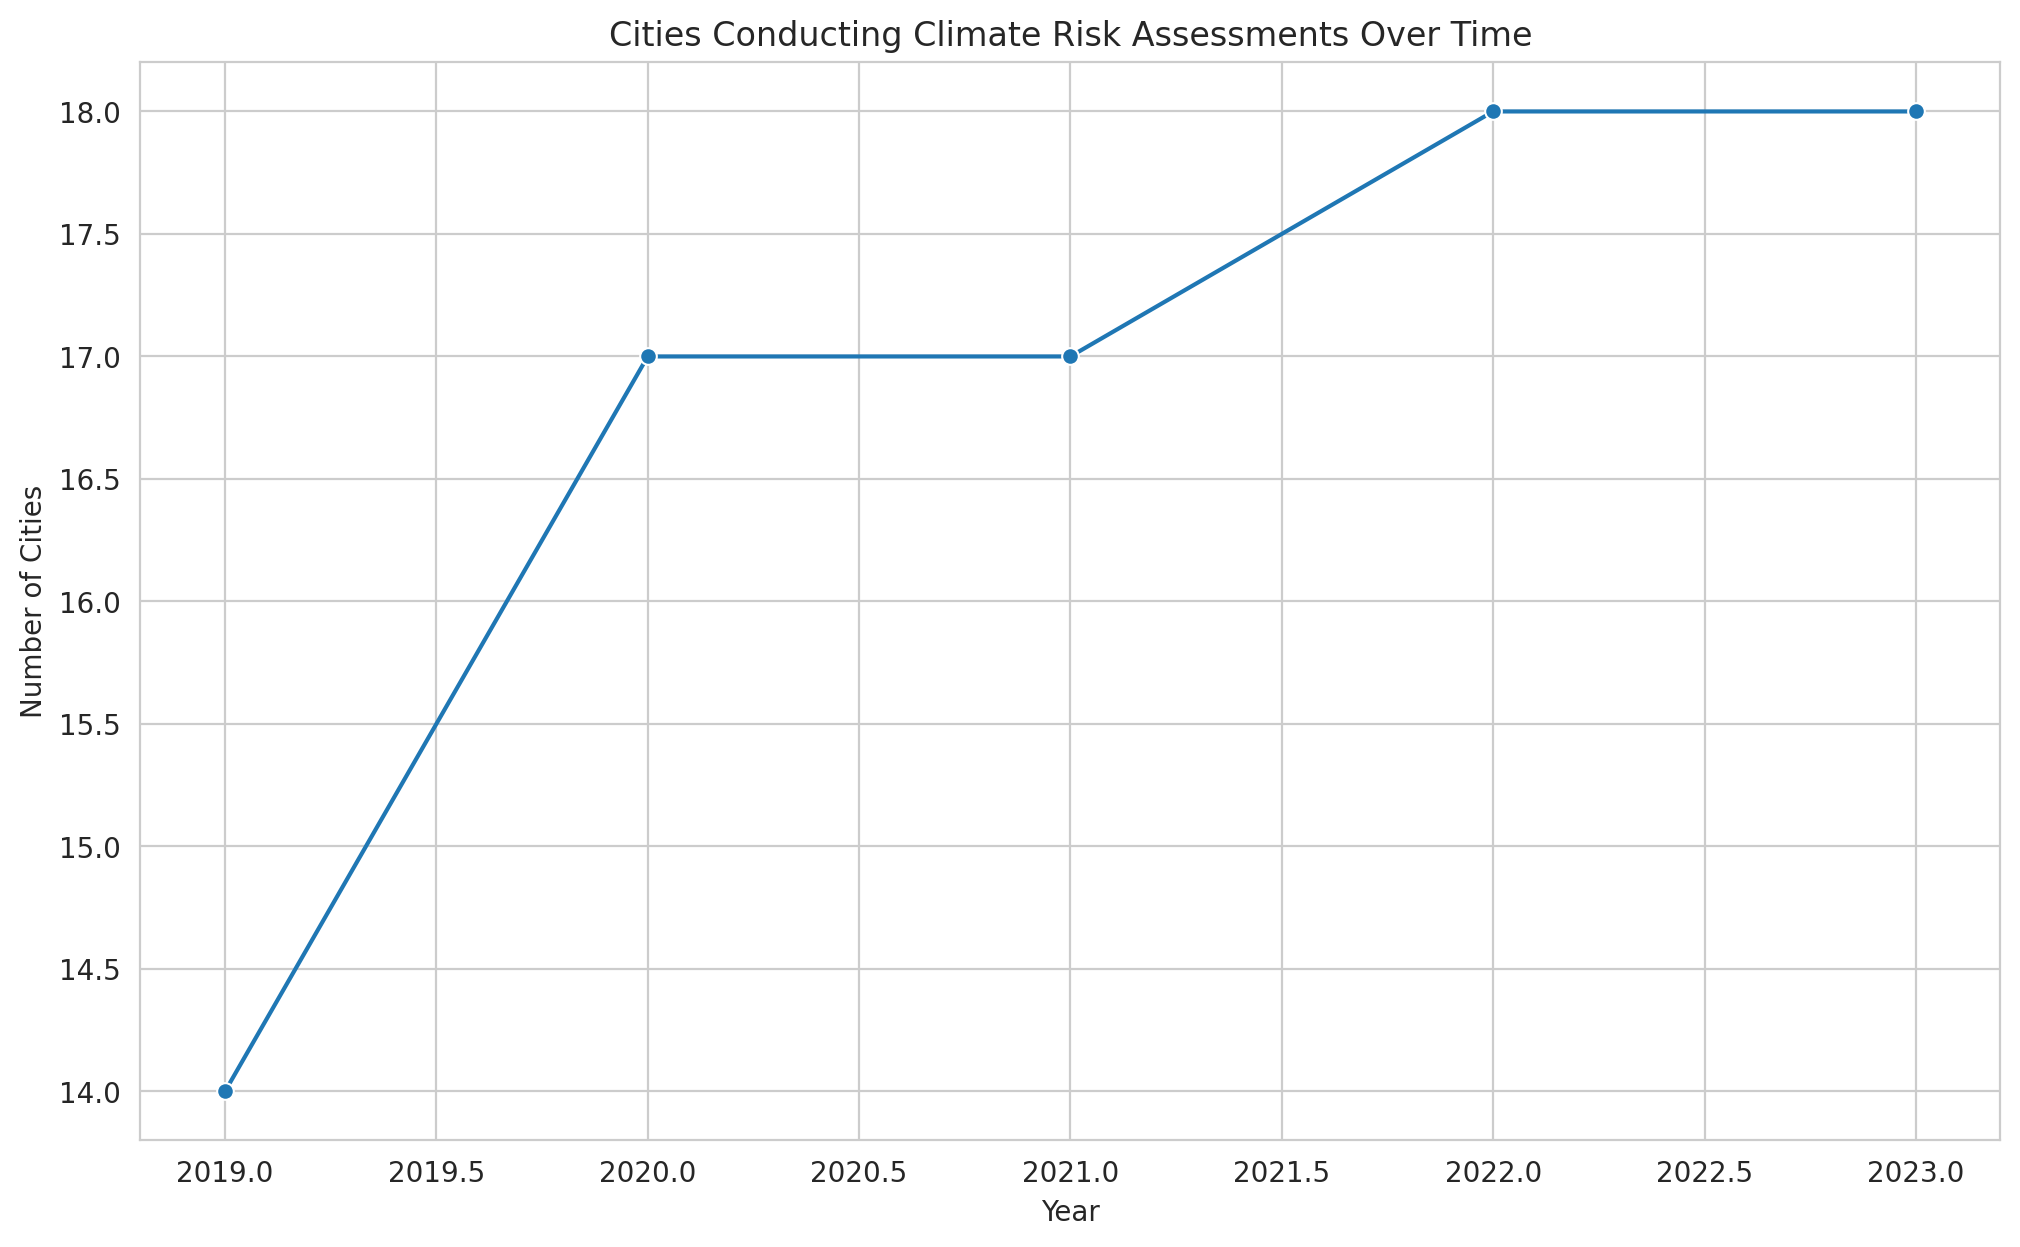

In [44]:
# Plot assessment trends
sns.lineplot(
    data=cities_per_year,
    x='CDP_response_year',
    y='num_cities_doing_assessment',
    marker='o'
)

plt.title("Cities Conducting Climate Risk Assessments Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cities")

plt.show()

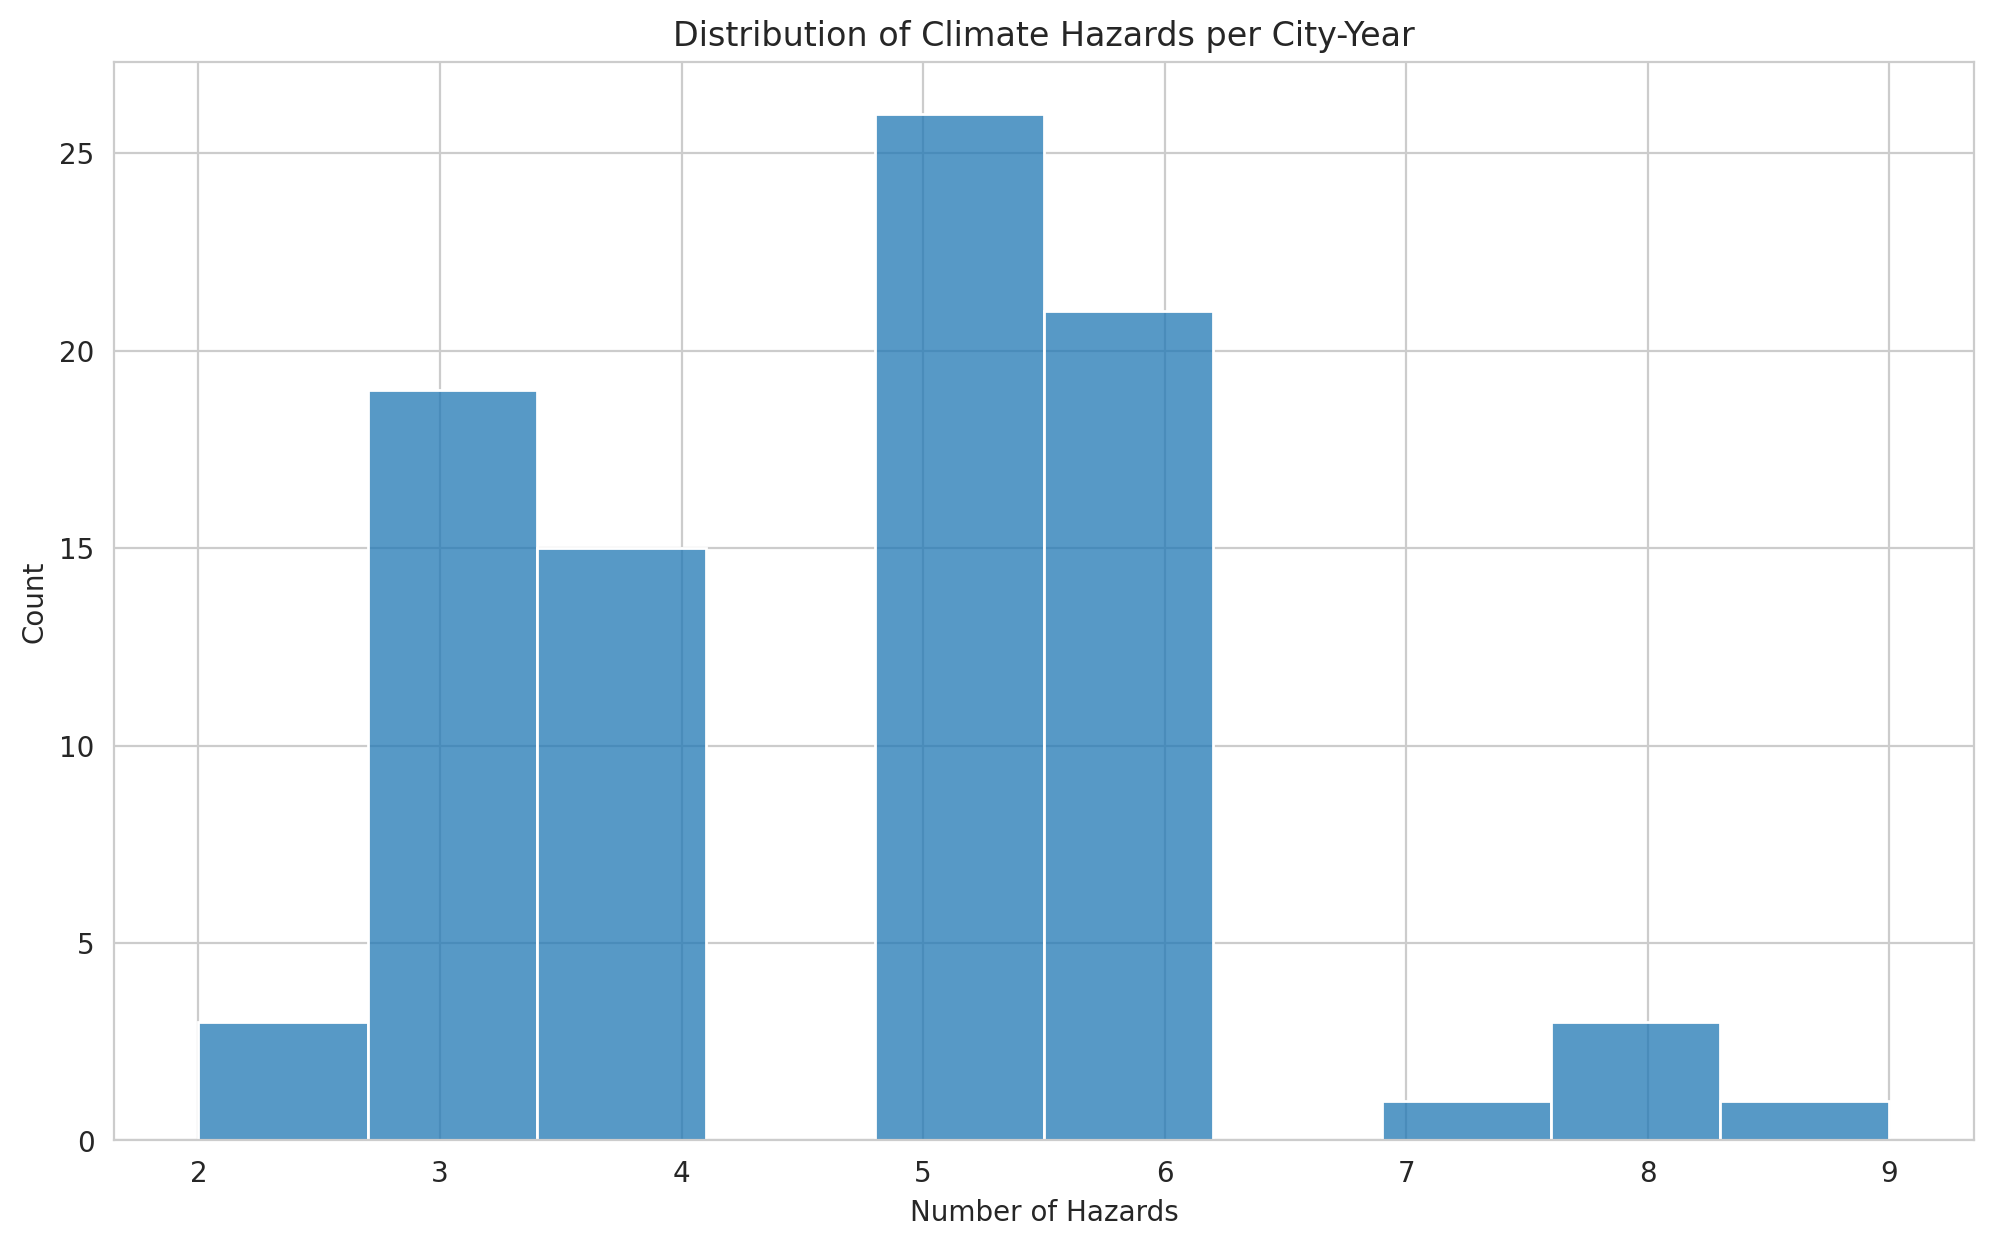

In [45]:
# Plotting hazar distribution
sns.histplot(df['num_hazards'], bins=10)

plt.title("Distribution of Climate Hazards per City-Year")
plt.xlabel("Number of Hazards")

plt.show()

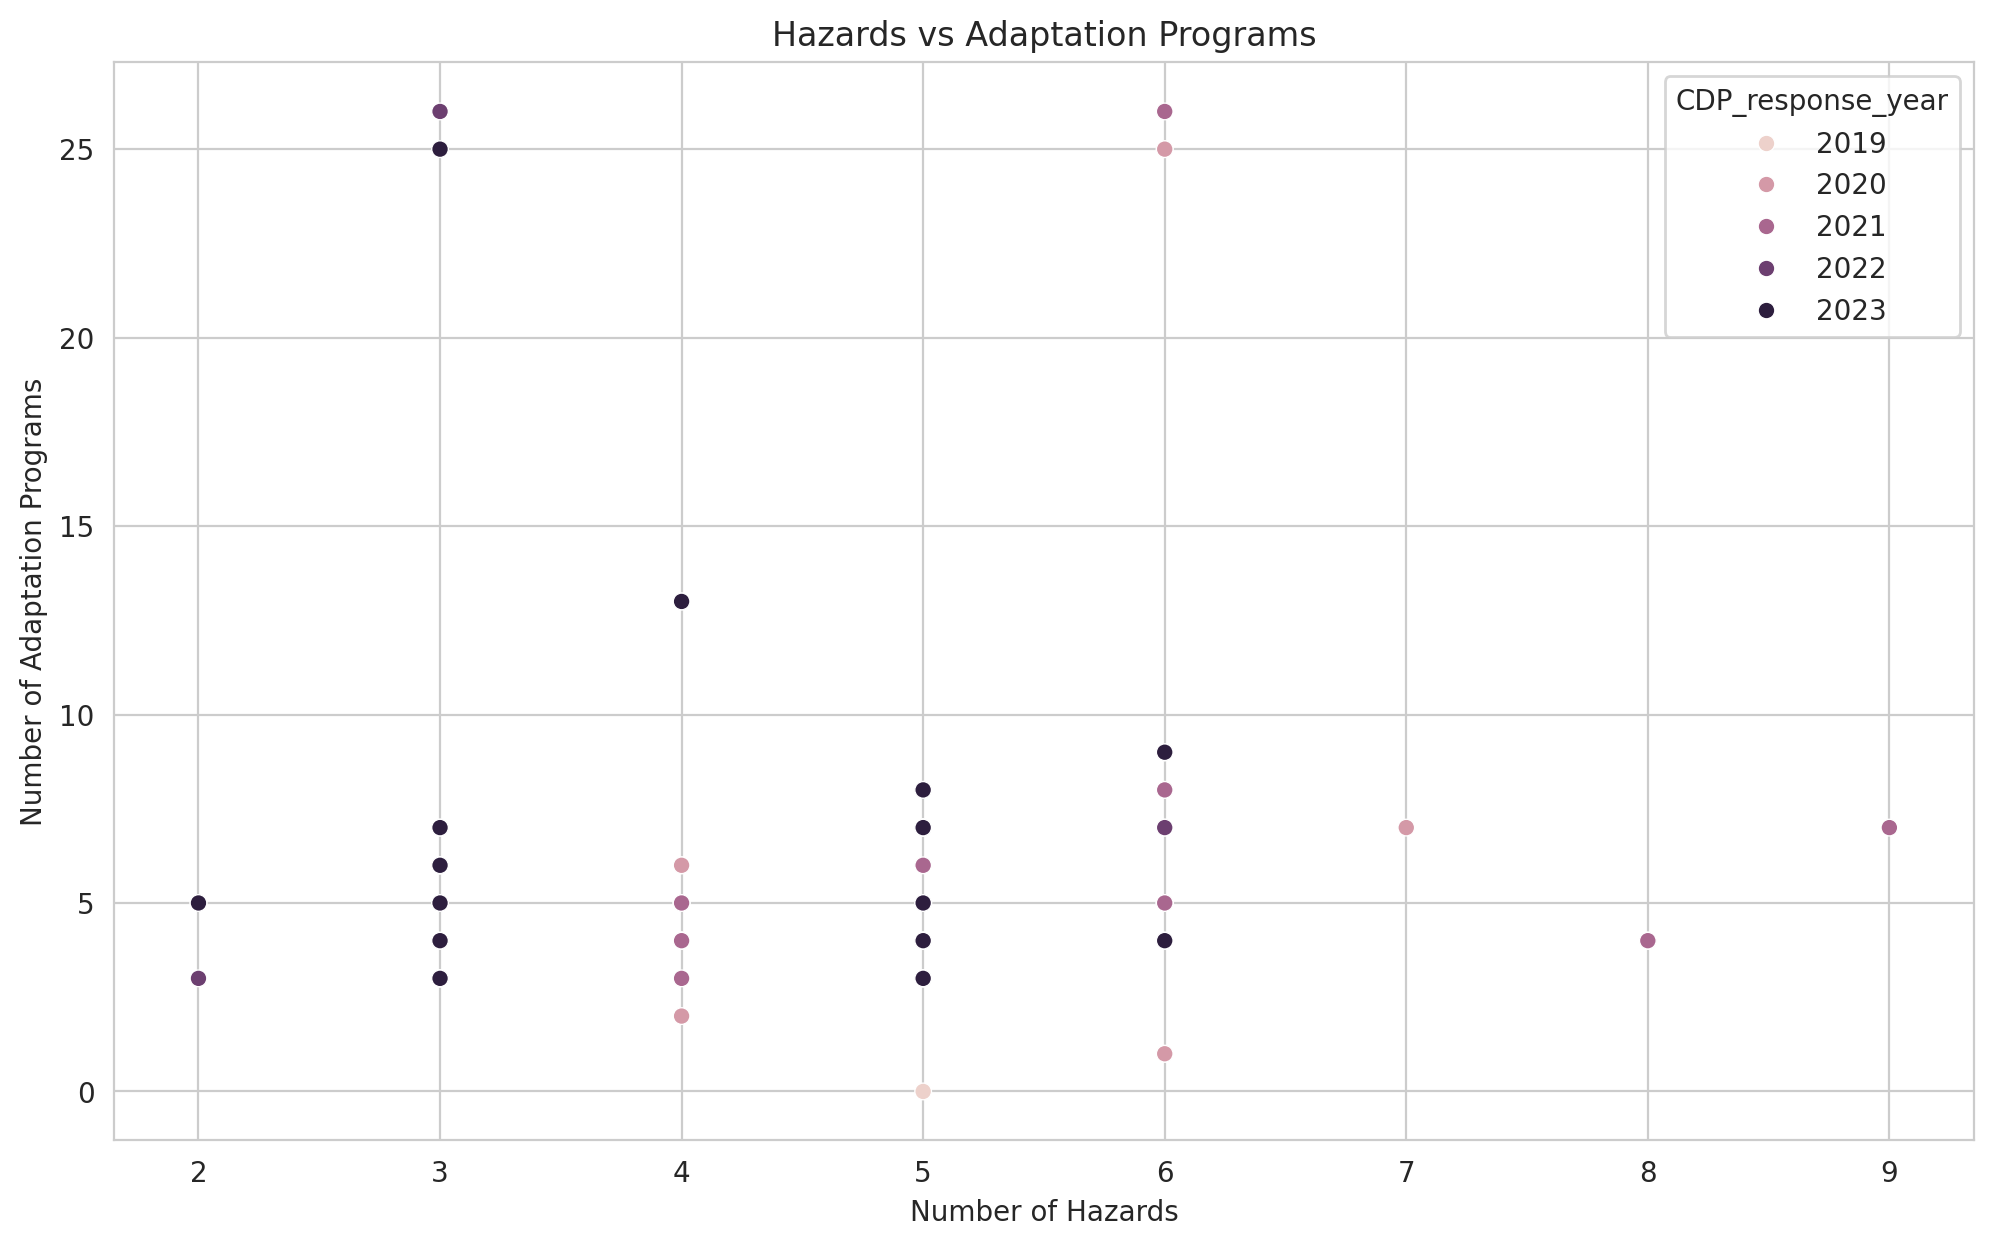

In [46]:
# Hazard vs Adaptation Programs Scatterplot
sns.scatterplot(
    data=df,
    x='num_hazards',
    y='num_adapt_programs',
    hue='CDP_response_year'
)

plt.title("Hazards vs Adaptation Programs")
plt.xlabel("Number of Hazards")
plt.ylabel("Number of Adaptation Programs")

plt.show()

In [77]:
print(df.columns)


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year',
       'num_hazards', 'most_common_hazard', 'population', 'population_year',
       'land_area_sqkm', 'num_adapt_programs', 'pop_density'],
      dtype='object')


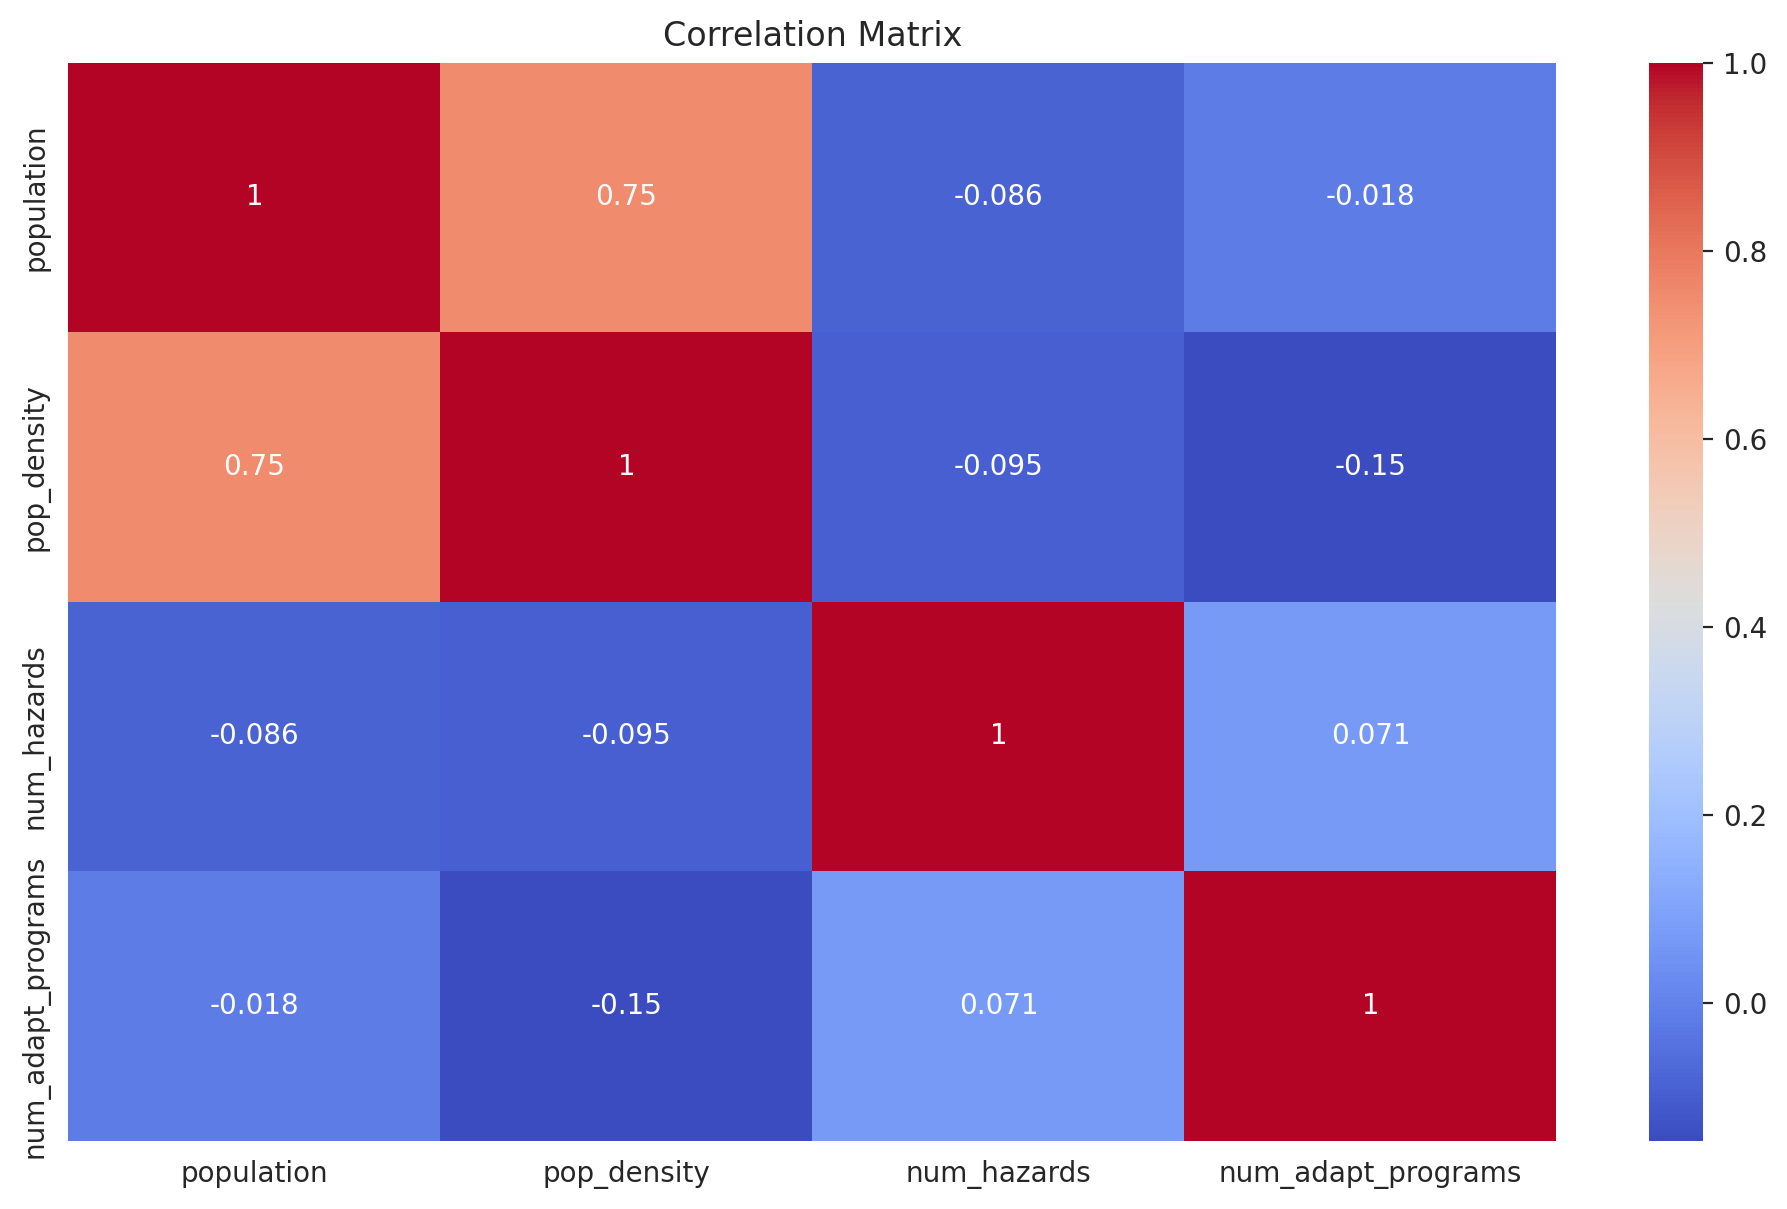

In [78]:
# Correlation matrix
numeric_cols = [
    'population',
    'pop_density',
    'num_hazards',
    'num_adapt_programs']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [0]:
# COVID analysis
covid_adapt = (
    df.groupby('covid_period')['num_adapt_programs']
    .mean()
    .reset_index()
)

sns.barplot(
    data=covid_adapt,
    x='covid_period',
    y='num_adapt_programs',
    order=['Pre-COVID', 'COVID-Impacted', 'Post-COVID']
)

)

plt.title("Average Adaptation Programs by COVID Period")

plt.show()


In [80]:
df.to_csv("capstone_city_climate_data.csv", index=False)

In [58]:
import os
os.listdir()


['2023_land_area.csv',
 '2021_adaptation.csv',
 '2023_assessment.csv',
 'capstone_city_climate_data.csv',
 '2020_population.csv',
 '2021_assessment.csv',
 '2023_hazards.csv',
 '2023_adaptation.csv',
 'cdp_capstone_analysis.ipynb',
 '2021_hazards.csv',
 '2022_population.csv',
 '.cdp_capstone_analysis.ipynb.sage-chat',
 '2019_population.csv',
 '2023_population.csv',
 '2022_hazards.csv',
 '2020_assessment.csv',
 '2019_adaptation.csv',
 '.cdp_capstone_analysis.ipynb.sage-jupyter2',
 '2020_hazards.csv',
 '2022_adaptation.csv',
 '2019_hazards.csv',
 '2021_population.csv',
 '2019_assessment.csv',
 '2020_adaptation.csv',
 '2022_assessment.csv']

OLD BELOW, NEW ABOVE


In [6]:
pop_2023 = pd.read_csv("2023_population.csv")

pop_2023.head()
pop_2023.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   city               18 non-null     object
 1   population         18 non-null     int64 
 2   population_year    18 non-null     int64 
 3   CDP_response_year  18 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 708.0+ bytes


Load all datasets



In [7]:
# Population and land area
pop_2023 = pd.read_csv("2023_population.csv")
land_2023 = pd.read_csv("2023_land_area.csv")

# Climate risk assessments
assess_2019 = pd.read_csv("2019_assessment.csv")
assess_2020 = pd.read_csv("2020_assessment.csv")
assess_2021 = pd.read_csv("2021_assessment.csv")
assess_2022 = pd.read_csv("2022_assessment.csv")
assess_2023 = pd.read_csv("2023_assessment.csv")

# Climate hazards
haz_2019 = pd.read_csv("2019_hazards.csv")
haz_2020 = pd.read_csv("2020_hazards.csv")
haz_2021 = pd.read_csv("2021_hazards.csv")
haz_2022 = pd.read_csv("2022_hazards.csv")
haz_2023 = pd.read_csv("2023_hazards.csv")

# Adaptation programs
adapt_2019 = pd.read_csv("2019_adaptation.csv")
adapt_2020 = pd.read_csv("2020_adaptation.csv")
adapt_2021 = pd.read_csv("2021_adaptation.csv")
adapt_2022 = pd.read_csv("2022_adaptation.csv")
adapt_2023 = pd.read_csv("2023_adaptation.csv")

Build panel dataset



In [8]:
# Combine assessment across years
assessment = pd.concat([assess_2019, assess_2020, assess_2021, assess_2022, assess_2023])

# Combine hazards across years
hazards = pd.concat([haz_2019, haz_2020, haz_2021, haz_2022, haz_2023])

In [9]:
# Aggregate hazards per city-year
hazards_agg = (
    hazards
    .groupby(['city','CDP_response_year'])
    .size()
    .reset_index(name='num_hazards'))

In [10]:
# Most common hazard type per city-year
most_common_hazard = (
    hazards.groupby(['city','CDP_response_year'])['most_sig_hazard']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .reset_index(name='most_common_hazard'))

# Count hazards per city-year 
hazards_agg = hazards.groupby(['city','CDP_response_year']).size().reset_index(name='num_hazards')

# Merge both together
hazards_agg = hazards_agg.merge(most_common_hazard, on=['city','CDP_response_year'])

# Merge aggregated hazards into your assessment panel
df = assessment.merge(hazards_agg, on=['city','CDP_response_year'], how='left')

# Check shape
print(df.shape)
df.head()

(90, 5)


,city,climate_risk_assessment_YN,CDP_response_year,num_hazards,most_common_hazard
0,New York,Yes,2019,5.0,Flood and sea level rise
1,Los Angeles,Yes,2019,6.0,Flood and sea level rise
2,Chicago,Yes,2019,6.0,Extreme Precipitation
3,Houston,No,2019,6.0,Extreme heat
4,Phoenix,Yes,2019,5.0,Extreme heat


In [11]:
df.columns


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year',
       'num_hazards', 'most_common_hazard'],
      dtype='object')

In [15]:
# Combine the two population columns
df['population'] = df['population_x'].fillna(df['population_y'])

# Drop the old columns
df = df.drop(columns=['population_x', 'population_y'])

# Check result
df.columns


KeyError: 'population_x'

In [13]:
df = assessment.copy()

In [14]:
df['population'] = df['population']
df = df.drop(columns=['population_x', 'population_y'])

df = df.rename(columns={'land_area_sqkm_x': 'land_area'})
df = df.drop(columns=['land_area_sqkm_y'])

df = df[['city', 'CDP_response_year', 'climate_risk_assessment_YN',
         'num_hazards', 'most_common_hazard',
         'population', 'land_area']]


KeyError: 'population'

In [16]:
print(df.columns)


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year'], dtype='object')


In [17]:
# Create a clean population column
df['population'] = df['population_x'].fillna(df['population_y'])

# Remove the duplicate columns
df.drop(columns=['population_x','population_y'], inplace=True)

# Verify
print(df.columns)


KeyError: 'population_x'

In [18]:
if 'population' not in df.columns:
    if 'population_x' in df.columns and 'population_y' in df.columns:
        df['population'] = df['population_x'].fillna(df['population_y'])
        df.drop(columns=['population_x','population_y'], inplace=True)

print(df.columns)


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year'], dtype='object')


In [20]:
df.head()


,city,climate_risk_assessment_YN,CDP_response_year
0,New York,Yes,2019
1,Los Angeles,Yes,2019
2,Chicago,Yes,2019
3,Houston,No,2019
4,Phoenix,Yes,2019


In [21]:
assessment = pd.read_csv("2023_assessment.csv")
hazards = pd.read_csv("2023_hazards.csv")
population = pd.read_csv("2023_population.csv")
adaptation = pd.read_csv("2023_adaptation.csv")
land = pd.read_csv("2023_land_area.csv")


In [22]:
df = assessment.merge(hazards, on=["city","CDP_response_year"], how="left")
df = df.merge(population, on=["city","CDP_response_year"], how="left")
df = df.merge(land, on=["city","CDP_response_year"], how="left")
df = df.merge(adaptation, on=["city","CDP_response_year"], how="left")


In [23]:
df.columns


Index(['city', 'climate_risk_assessment_YN', 'CDP_response_year',
       'most_sig_hazard', 'probability', 'magnitude_x',
       'expected_intensity_change', 'expected_frequency_change',
       'timeframe_expected_change', 'population_exposed', 'population',
       'population_year', 'land_area_sqkm', 'factors_affect_adaptability',
       'challenge_or_support', 'magnitude_y', 'description'],
      dtype='object')

In [30]:
df = df.merge(hazards_agg, on=['city','CDP_response_year'], how='left')

print(df.shape)
df.head()

(11892, 36)


,city,climate_risk_assessment_YN,CDP_response_year,most_sig_hazard_x,probability_x,magnitude_x,expected_intensity_change_x,expected_frequency_change_x,timeframe_expected_change_x,social_impact_x,...,magnitude,expected_intensity_change,expected_frequency_change,timeframe_expected_change,social_impact,assets_services_affected,vulnerable_populations,population_exposed,num_hazards_y,num_hazards
0,New York,Yes,2019,Extreme Precipitation,Medium High,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,...,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,Public health; Residential; Water supply & san...,Persons with disabilities; Marginalized groups...,NaN,5.0,5.0
1,New York,Yes,2019,Extreme Precipitation,Medium High,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,...,Medium,Do not know,Do not know,Immediately,Increased demand for public services; Increase...,Energy; Transport; Public health,Elderly; Low-income households; Persons living...,NaN,5.0,5.0
2,New York,Yes,2019,Extreme Precipitation,Medium High,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,...,High,Increasing,Increasing,Immediately,Increased incidence and prevalence of disease ...,Public health; Energy; Information & communica...,Marginalized groups; Unemployed persons; Child...,NaN,5.0,5.0
3,New York,Yes,2019,Extreme Precipitation,Medium High,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,...,High,Increasing,Increasing,Immediately,Loss of tax base to support public services; L...,Energy; Water supply & sanitation; Transport,Persons living in sub-standard housing; Person...,NaN,5.0,5.0
4,New York,Yes,2019,Extreme Precipitation,Medium High,Medium,Increasing,Increasing,Immediately,Population displacement; Increased resource de...,...,Medium,Increasing,Increasing,Short-term (by 2025),Increased resource demand; Loss of tax base to...,Residential; Public health; Commercial,Marginalized groups; Children & youth; Persons...,NaN,5.0,5.0


In [51]:
# Combine adaptation datasets
adapt_all = pd.concat([adapt_2019, adapt_2020, adapt_2021, adapt_2022, adapt_2023])

# Count number of programs per city-year
adapt_agg = adapt_all.groupby(['city', 'CDP_response_year']).size().reset_index(name='num_adapt_programs')

# Merge into main df
df = df.merge(adapt_agg, on=['city','CDP_response_year'], how='left')
df['num_adapt_programs'] = df['num_adapt_programs'].fillna(0)


Summary Statistics



In [48]:
# Compute population density
df['pop_density'] = df['population'] / df['land_area']


In [52]:
df.describe()
df['climate_risk_assessment_YN'].value_counts()
df['most_common_hazard'].value_counts()


most_common_hazard
Extreme heat                31
Extreme Precipitation       20
Flood and sea level rise    13
Biological hazards          12
Extreme cold                 6
Chemical change              5
Air pollution                1
Storm and wind               1
Name: count, dtype: int64

In [53]:
# Cities doing assessments per year
cities_per_year = df[df['climate_risk_assessment_YN']=='Yes'] \
    .groupby('CDP_response_year')['city'].nunique() \
    .reset_index(name='num_cities_doing_assessment')

print("Cities conducting climate risk assessments per year:")
print(cities_per_year)

Cities conducting climate risk assessments per year:
   CDP_response_year  num_cities_doing_assessment
0               2019                           14
1               2020                           17
2               2021                           17
3               2022                           18
4               2023                           18


In [61]:
# Poplulation nd density ranges
pop_stats = df['population'].describe()
density_stats = df['pop_density'].describe()

print("\nPopulation summary:")
print(pop_stats)

print("\nPopulation density summary:")
print(density_stats)


Population summary:
count    9.000000e+01
mean     1.836252e+06
std      1.867154e+06
min      7.132520e+05
25%      8.977200e+05
50%      1.292958e+06
75%      1.657035e+06
max      8.804190e+06
Name: population, dtype: float64

Population density summary:
count       90.000000
mean      2987.666077
std       2572.006258
min        711.715853
25%       1230.167038
50%       1972.758979
75%       4162.650602
max      11316.439589
Name: pop_density, dtype: float64


Trend Analysis Over Time



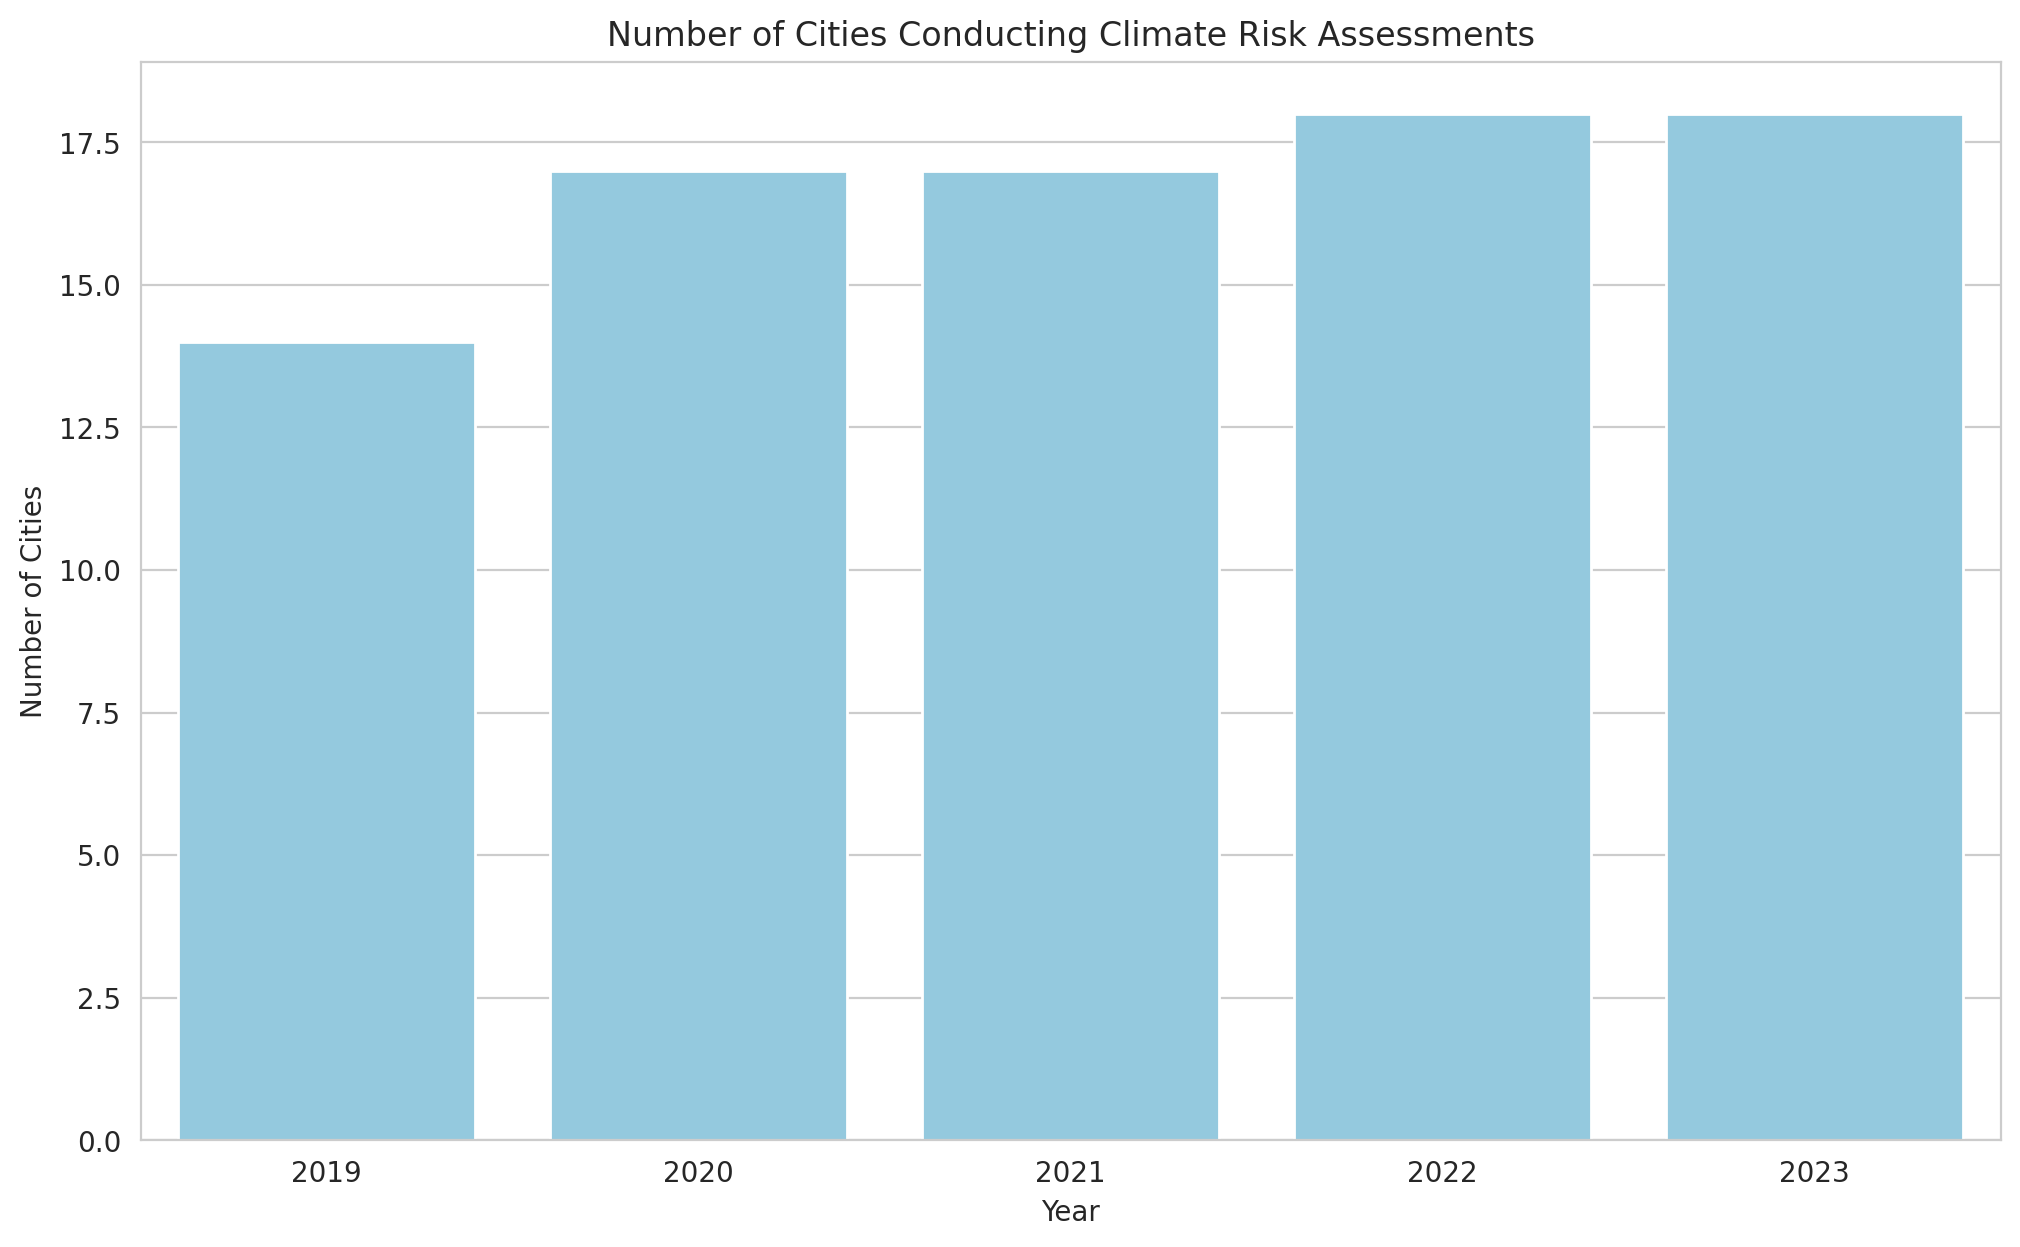

In [54]:
# Cities conducting climate risk assessments
sns.barplot(data=cities_per_year, x='CDP_response_year', y='num_cities_doing_assessment', color='skyblue')
plt.title("Number of Cities Conducting Climate Risk Assessments")
plt.ylabel("Number of Cities")
plt.xlabel("Year")
plt.show()

In [63]:
# Hazards per city-year
hazard_stats = df['num_hazards'].describe()
print("\nNumber of hazards reported per city-year:")
print(hazard_stats)


Number of hazards reported per city-year:
count    89.000000
mean      4.707865
std       1.423841
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       9.000000
Name: num_hazards, dtype: float64


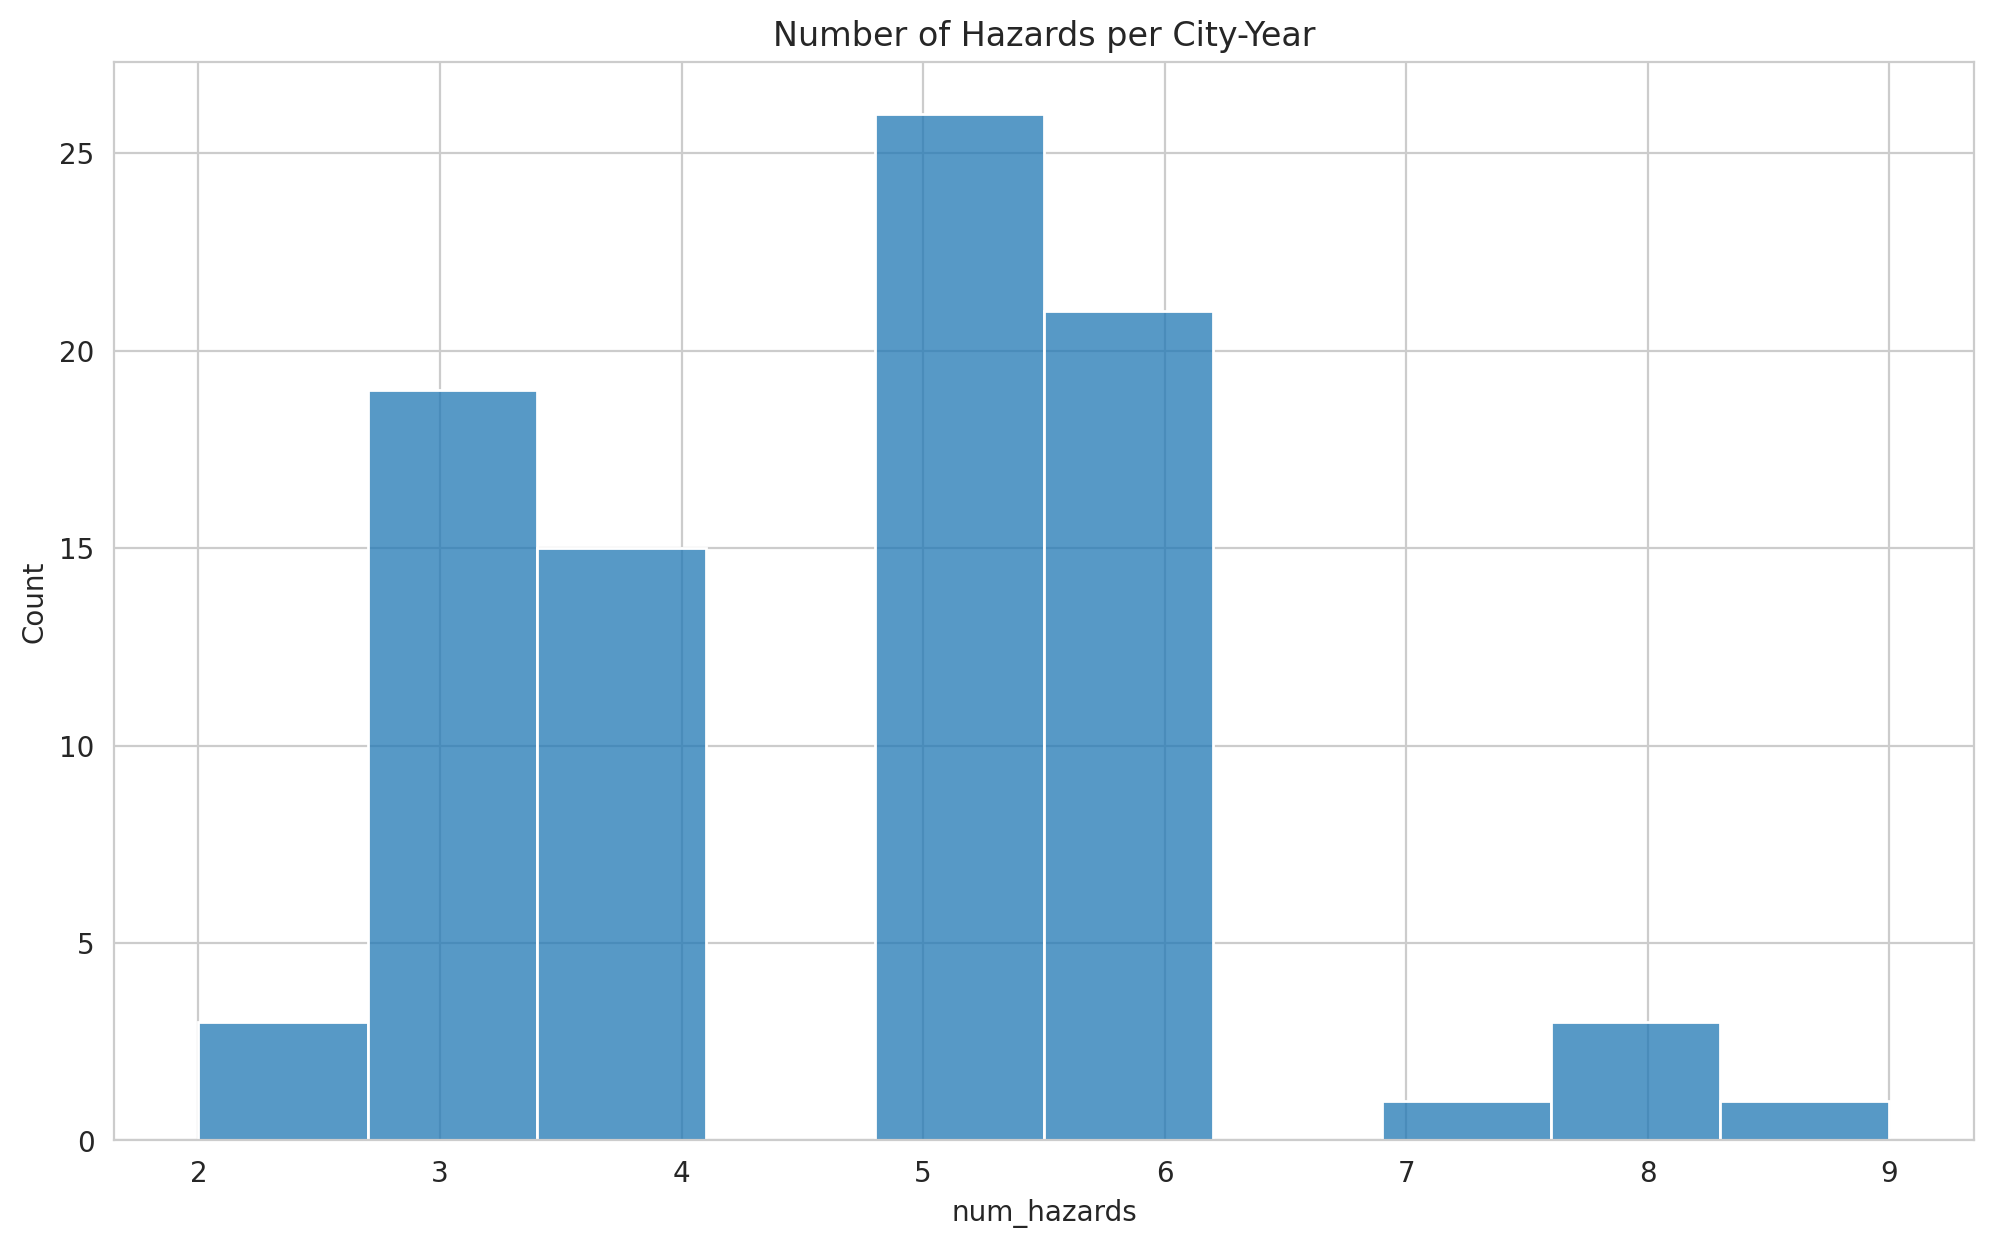

In [64]:
# Plotting hazards per city-year
sns.histplot(df['num_hazards'], bins=10, kde=False)
plt.title("Number of Hazards per City-Year")
plt.show()

In [65]:
# Most common hazard types overall
most_common_hazards = df['most_common_hazard'].value_counts().reset_index()
most_common_hazards.columns = ['hazard_type','num_city_years']

print("\nMost common hazard types (city-year counts):")
print(most_common_hazards)


Most common hazard types (city-year counts):
                hazard_type  num_city_years
0              Extreme heat              31
1     Extreme Precipitation              20
2  Flood and sea level rise              13
3        Biological hazards              12
4              Extreme cold               6
5           Chemical change               5
6             Air pollution               1
7            Storm and wind               1


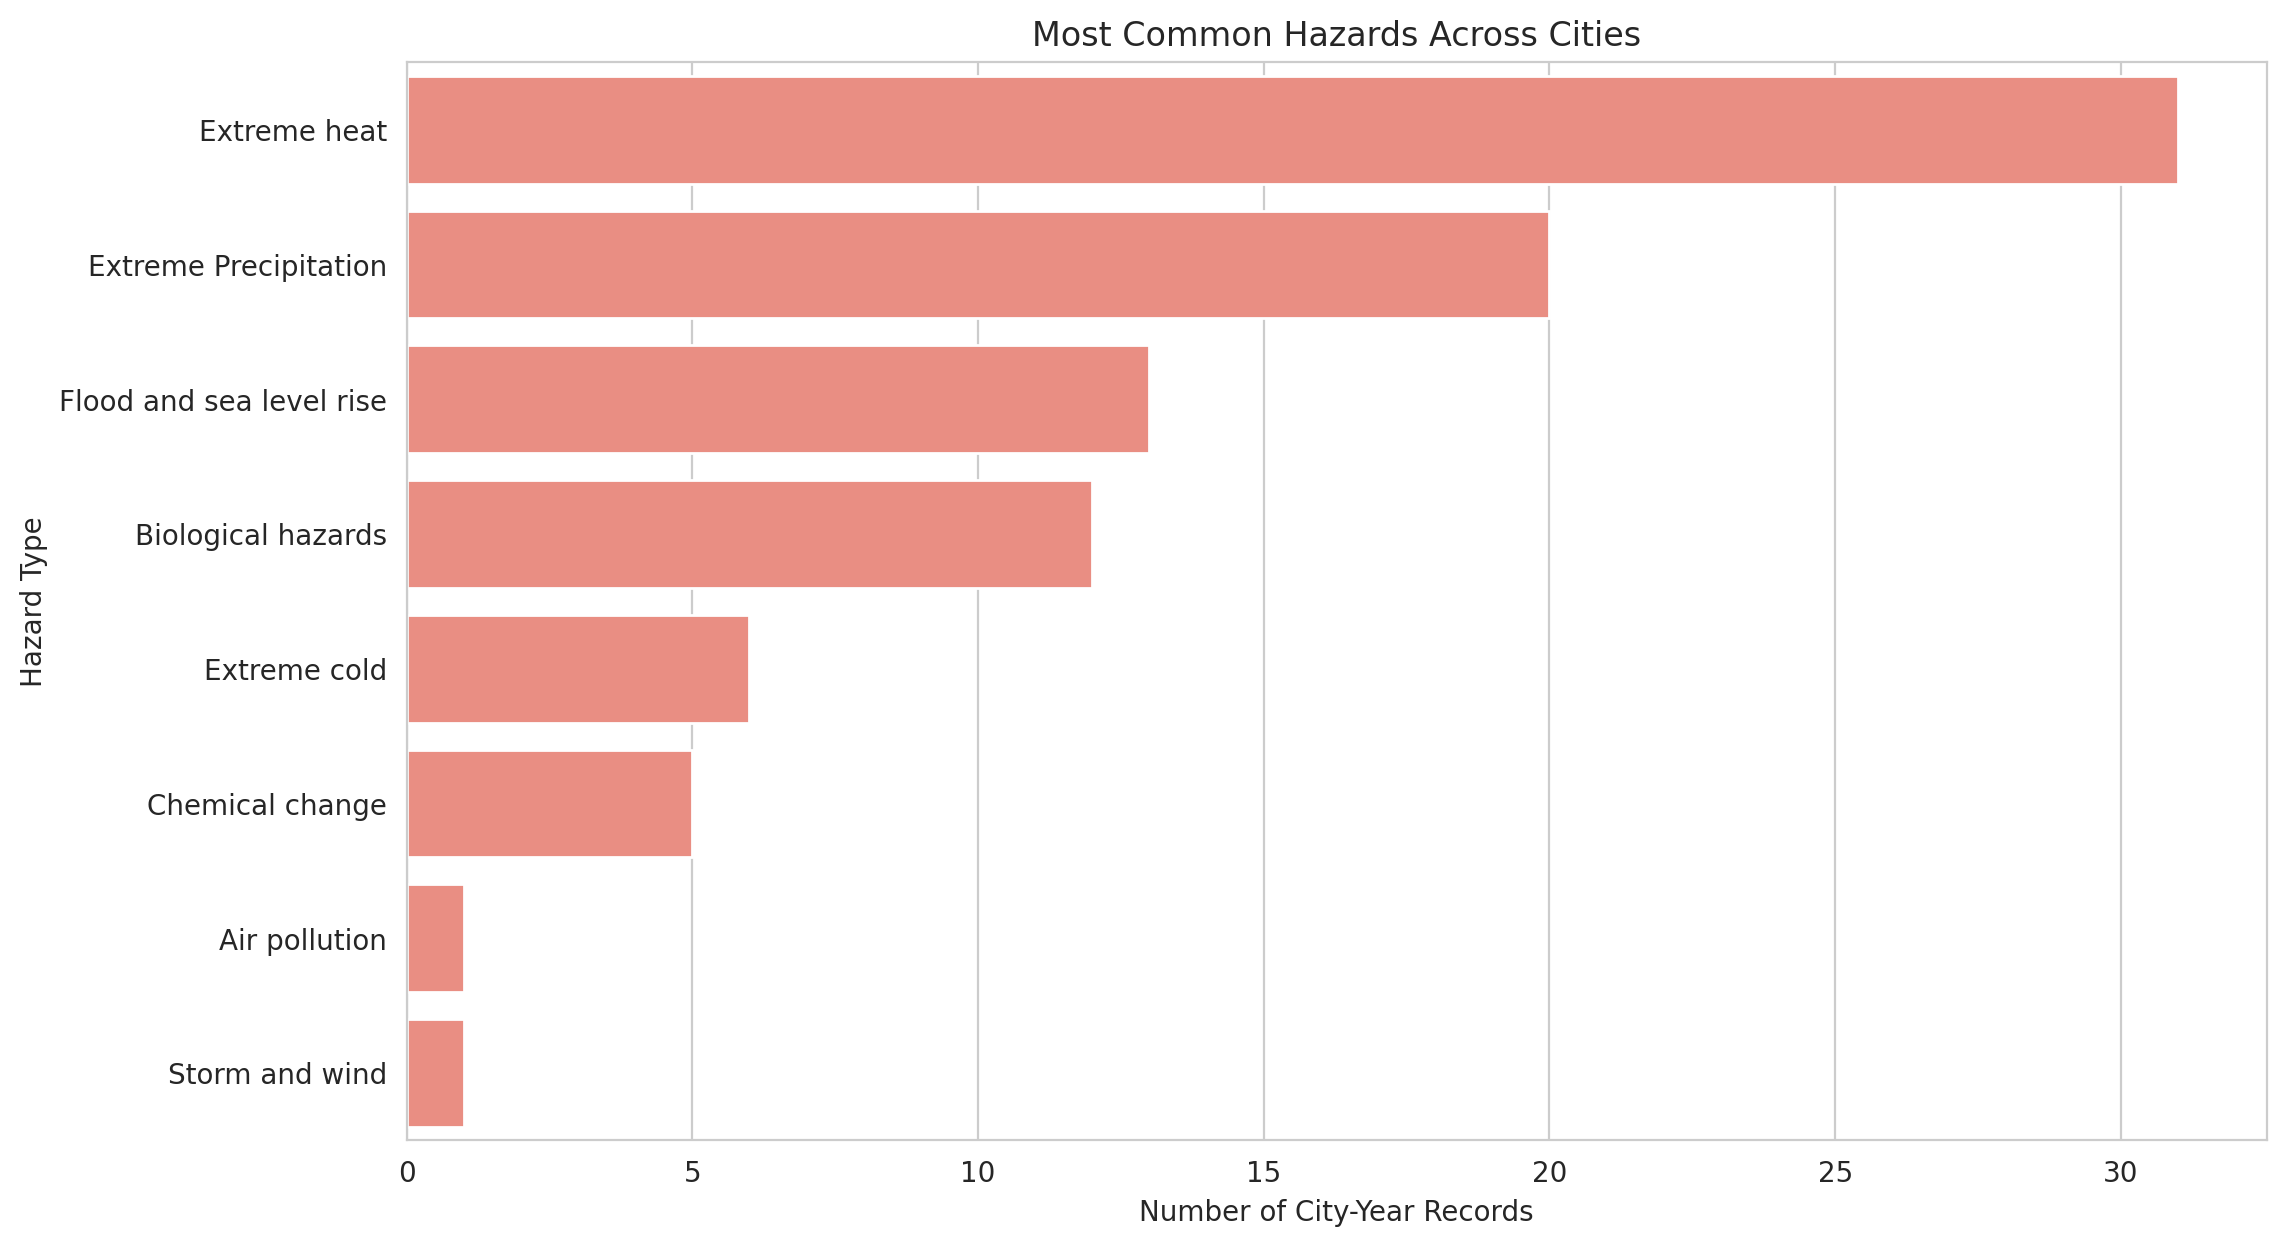

In [66]:
sns.barplot(data=most_common_hazards, x='num_city_years', y='hazard_type', color='salmon')
plt.title("Most Common Hazards Across Cities")
plt.xlabel("Number of City-Year Records")
plt.ylabel("Hazard Type")
plt.show()

Exploring adaptation programs: 

How many adaptation programs cities have per year

Whether cities with more hazards have more adaptation programs.



In [67]:
# Summary statistics
adapt_stats = df['num_adapt_programs'].describe()
print("Adaptation programs per city-year:")
print(adapt_stats)

Adaptation programs per city-year:
count    90.000000
mean      6.400000
std       5.166443
min       0.000000
25%       4.000000
50%       5.000000
75%       7.000000
max      26.000000
Name: num_adapt_programs, dtype: float64


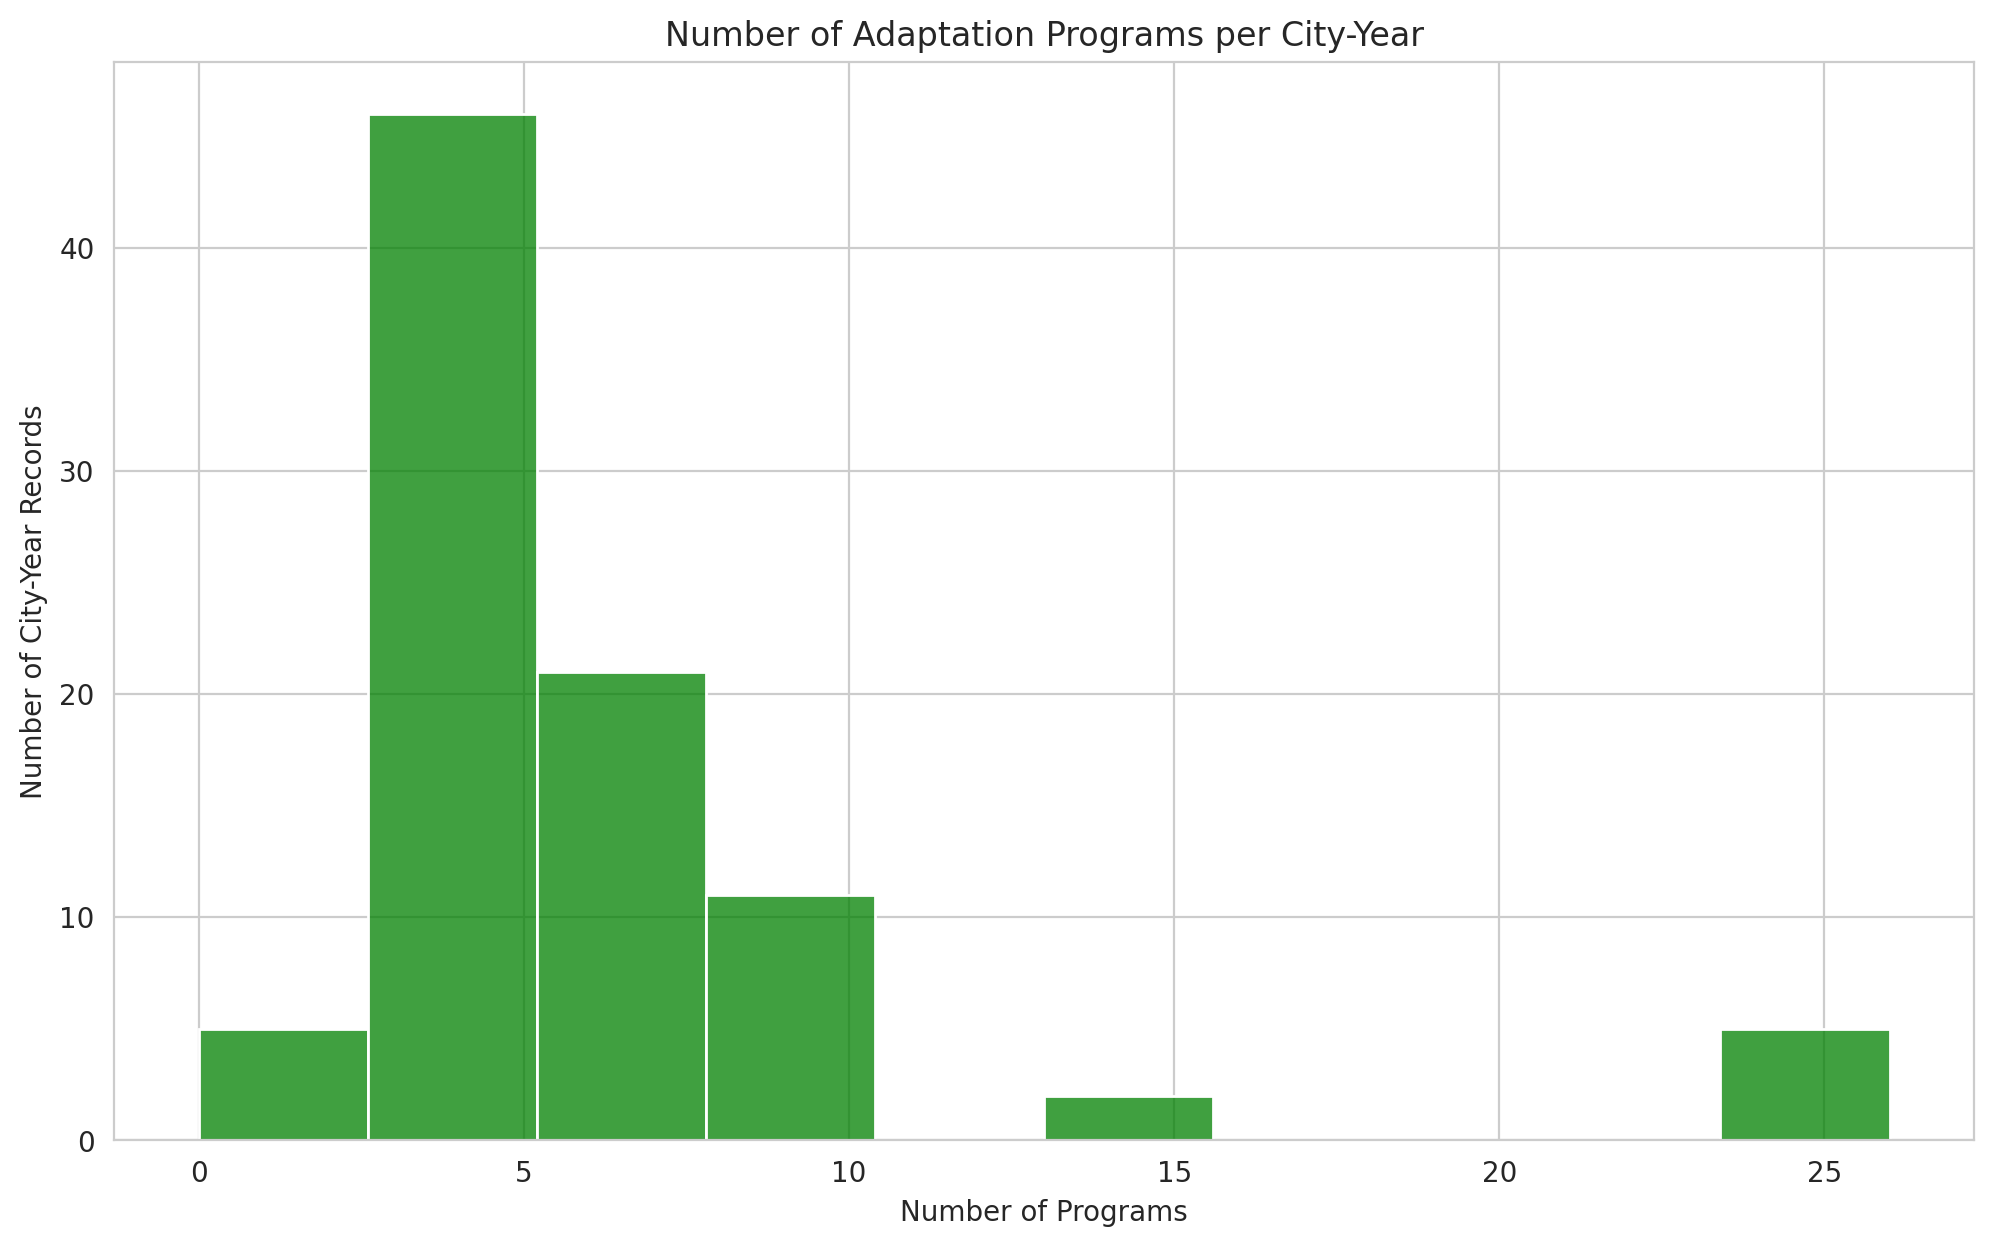

In [68]:
# Histogram
sns.histplot(df['num_adapt_programs'], bins=10, kde=False, color='green')
plt.title("Number of Adaptation Programs per City-Year")
plt.xlabel("Number of Programs")
plt.ylabel("Number of City-Year Records")
plt.show()

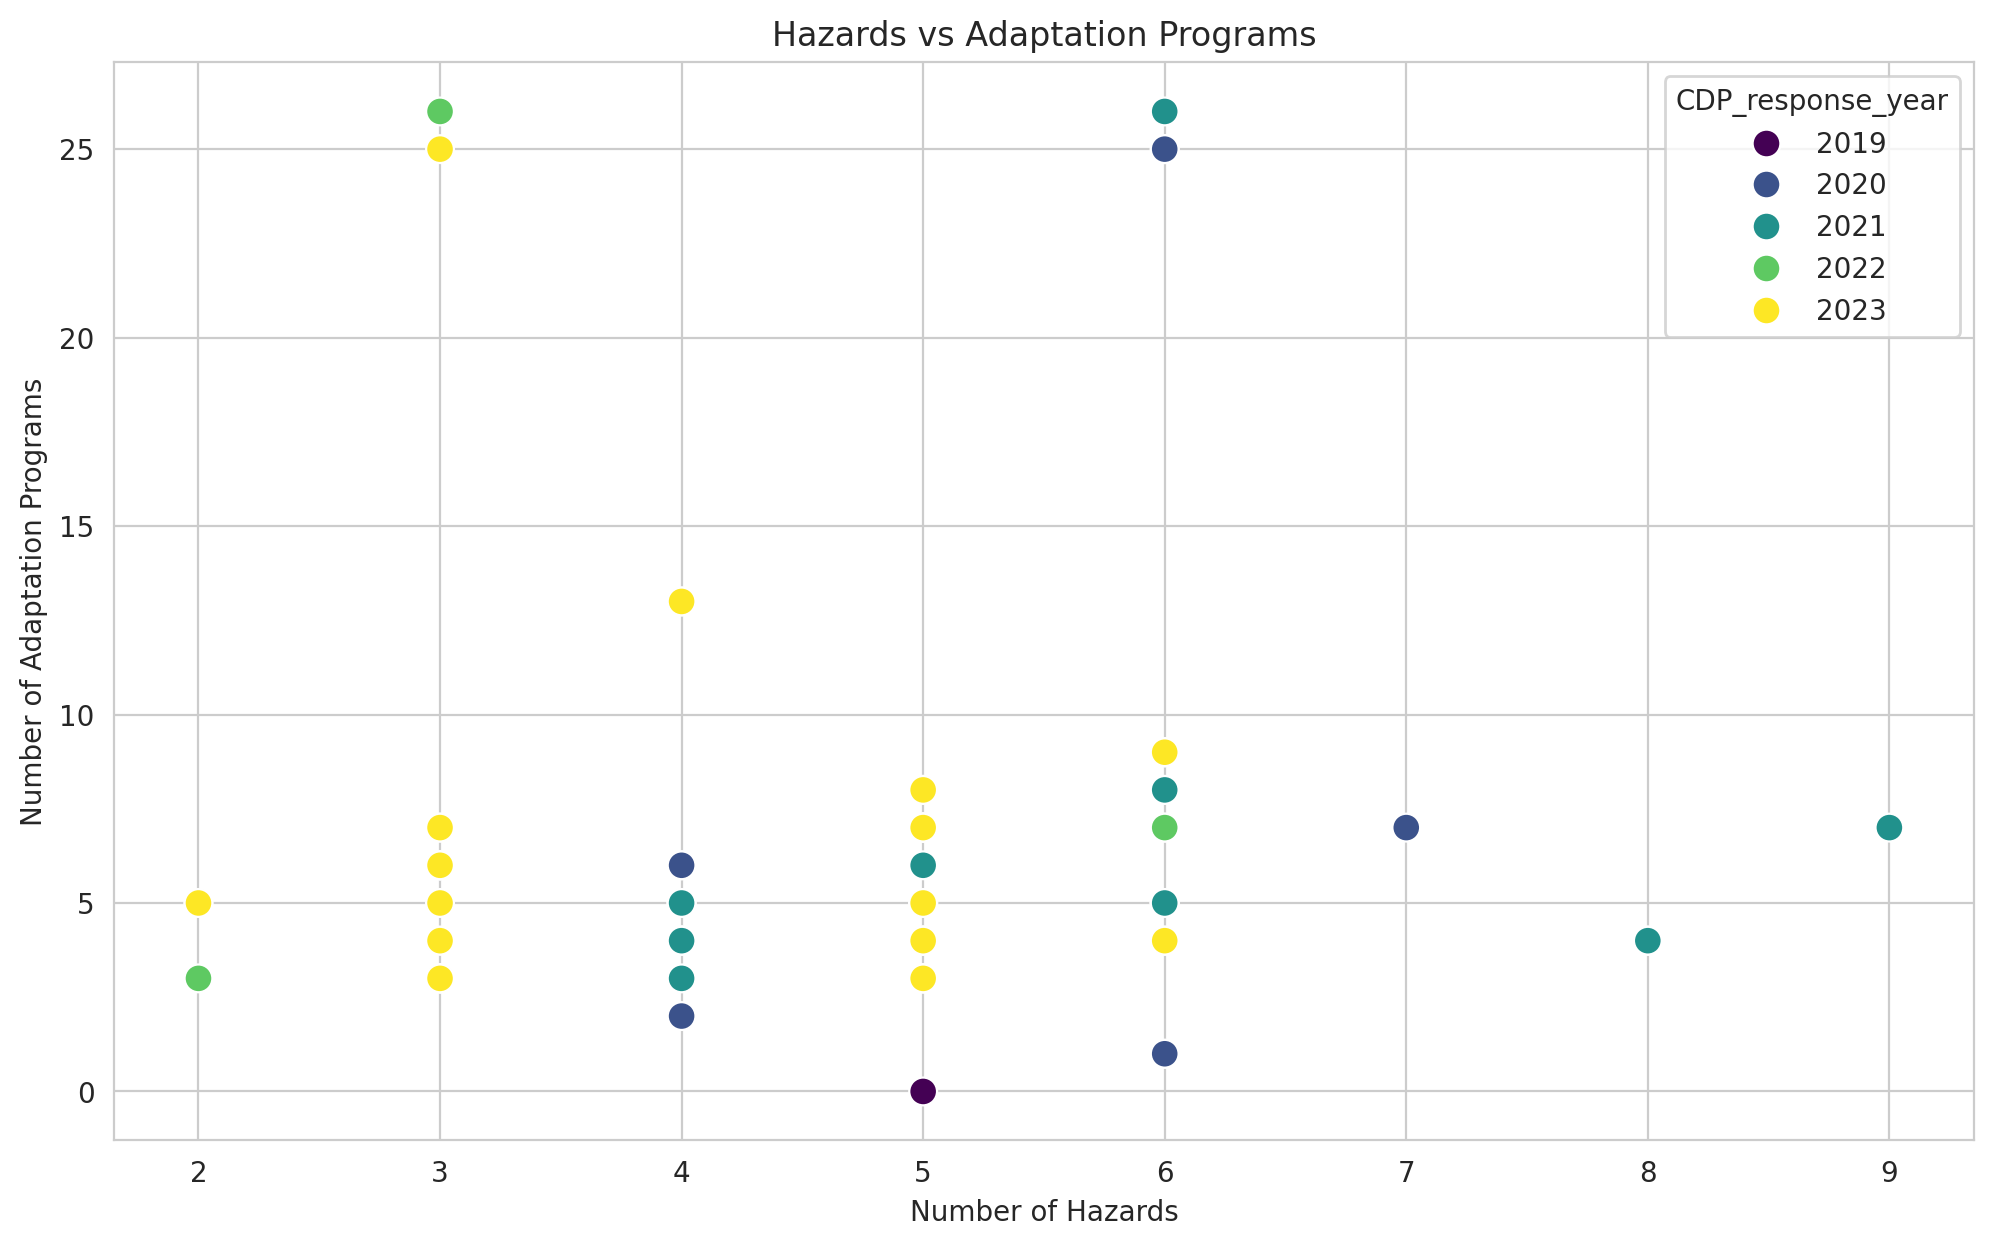

In [69]:
# Scatterlot: hazards vs adaptation
sns.scatterplot(data=df, x='num_hazards', y='num_adapt_programs', hue='CDP_response_year', palette='viridis', s=100)
plt.title("Hazards vs Adaptation Programs")
plt.xlabel("Number of Hazards")
plt.ylabel("Number of Adaptation Programs")
plt.show()

Compare population/density with hazards

Looking at whether larger or denser cities report more hazards



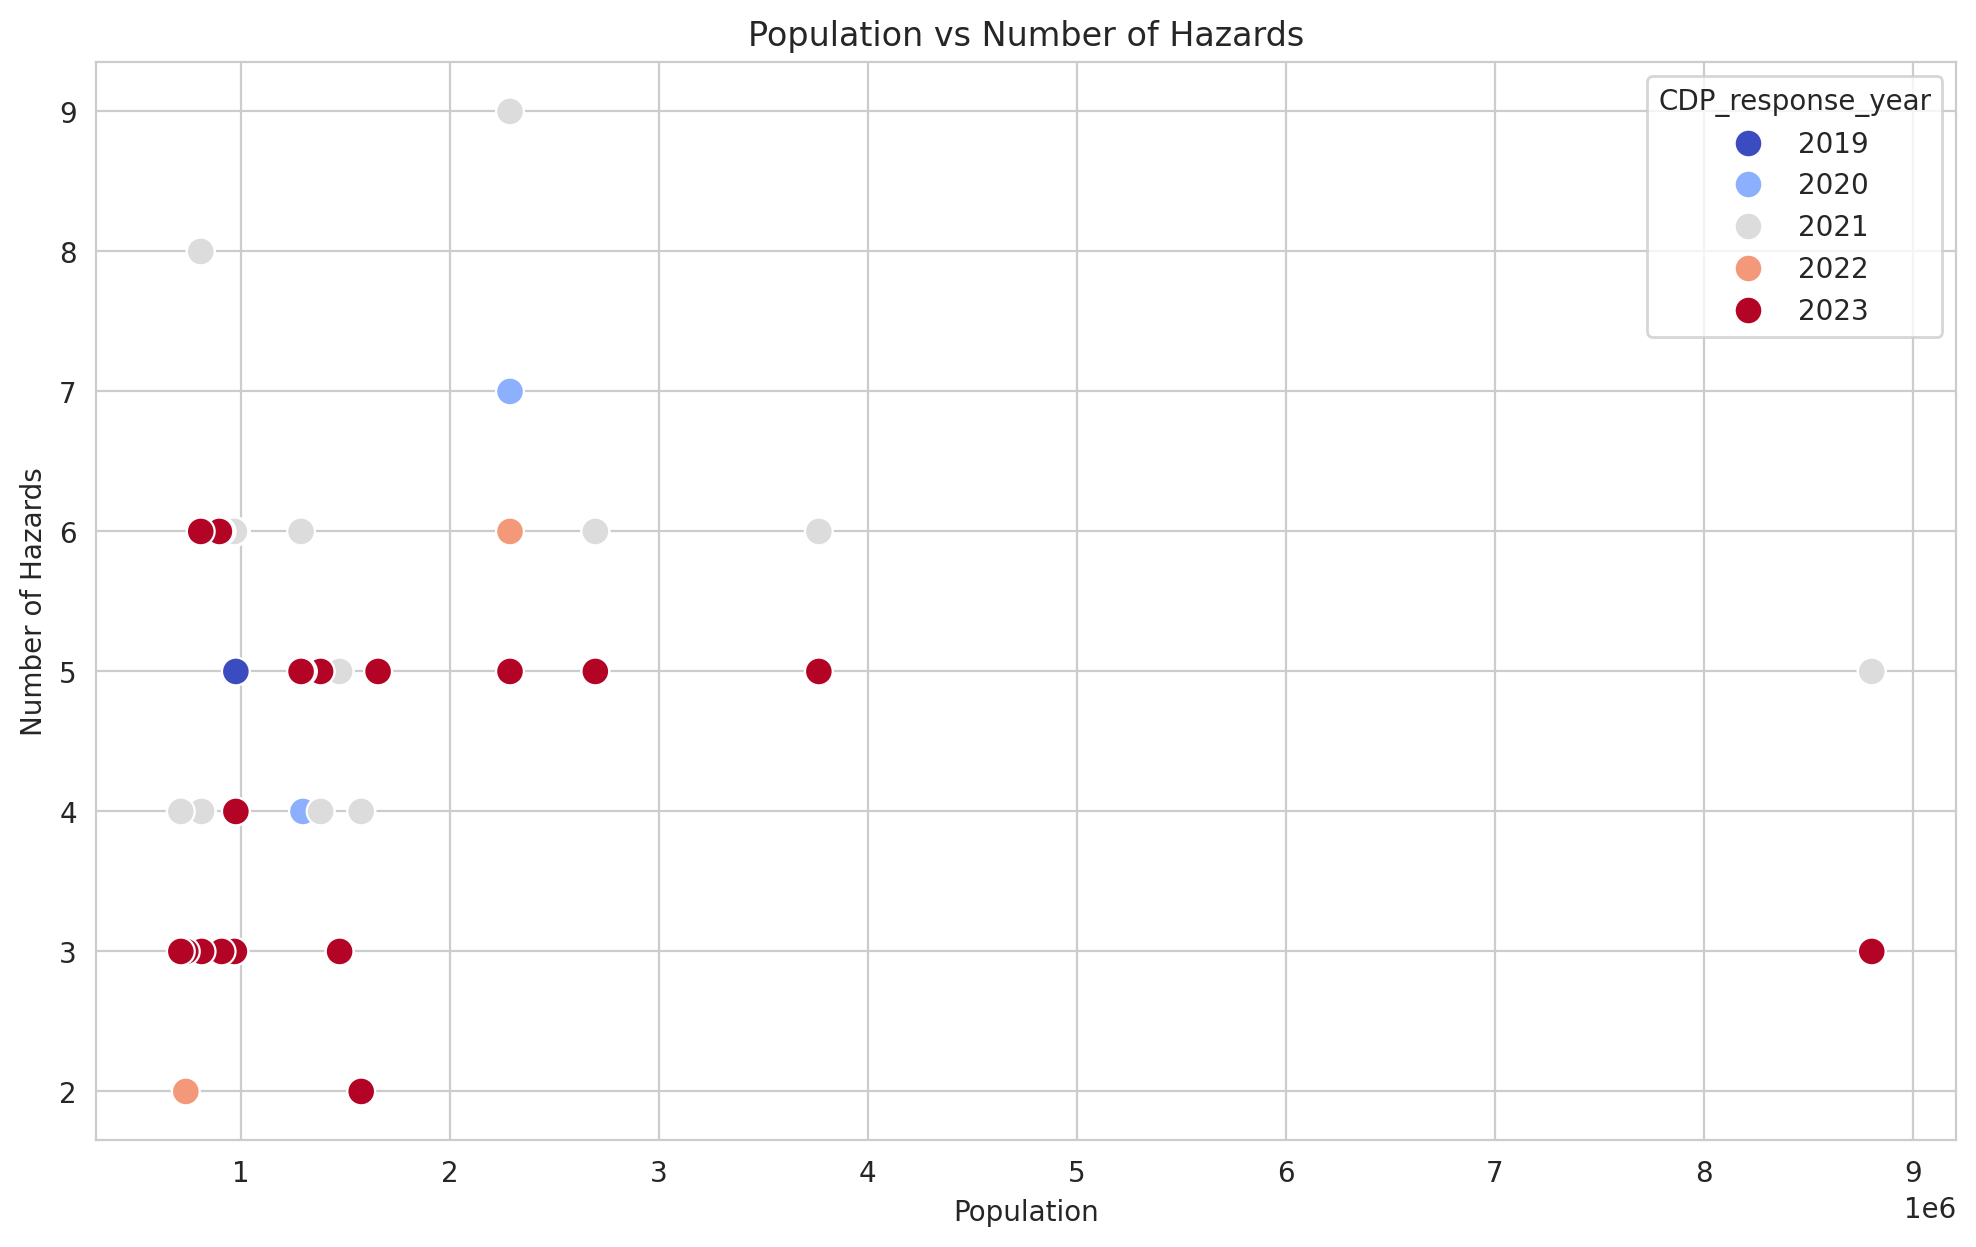

In [70]:
# Population vs hazards
sns.scatterplot(data=df, x='population', y='num_hazards', hue='CDP_response_year', palette='coolwarm', s=100)
plt.title("Population vs Number of Hazards")
plt.xlabel("Population")
plt.ylabel("Number of Hazards")
plt.show()

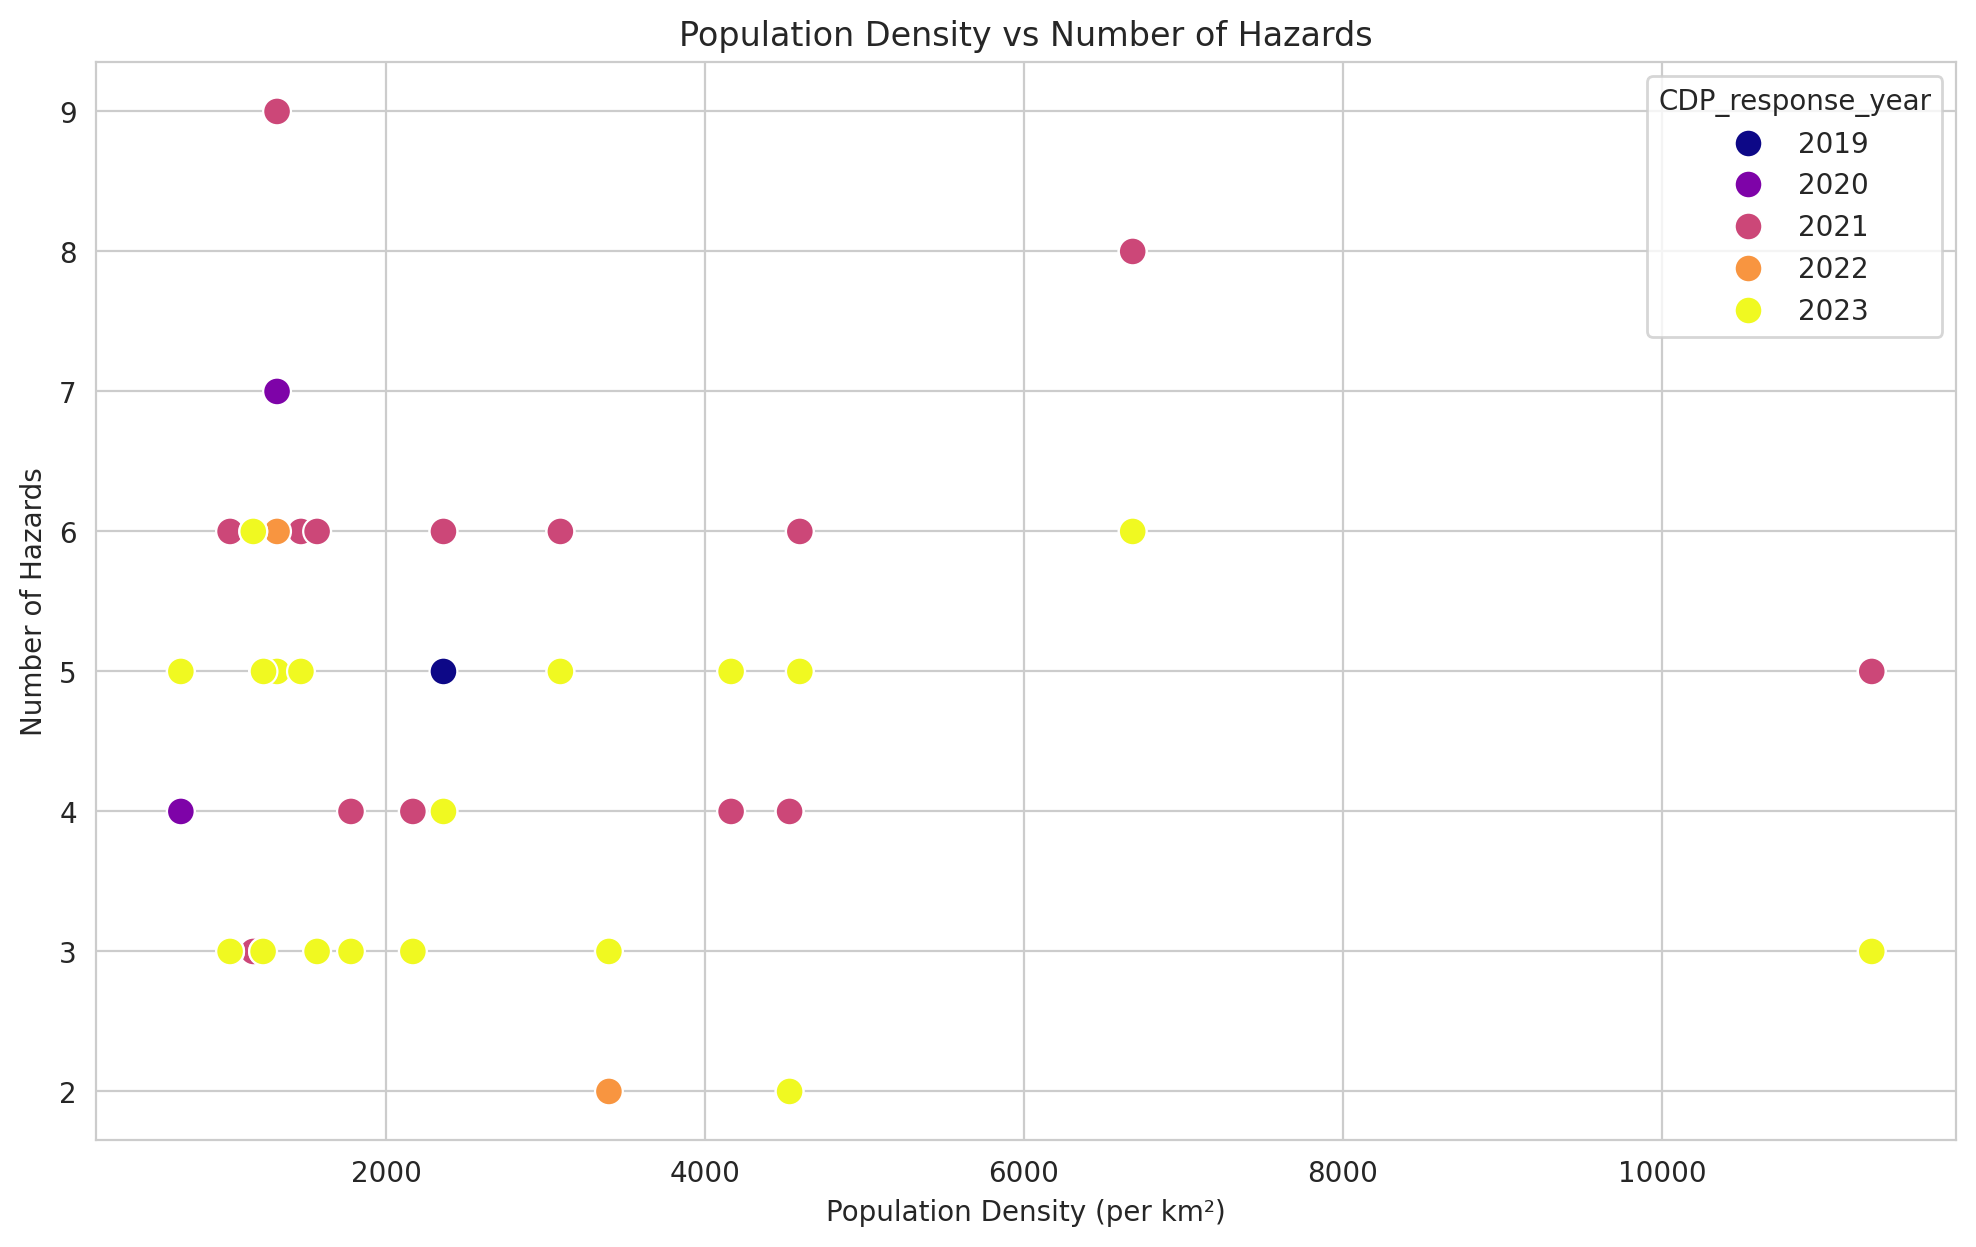

In [71]:
# Population density vs hazards
sns.scatterplot(data=df, x='pop_density', y='num_hazards', hue='CDP_response_year', palette='plasma', s=100)
plt.title("Population Density vs Number of Hazards")
plt.xlabel("Population Density (per km²)")
plt.ylabel("Number of Hazards")
plt.show()

Insight: Denser cities may face more risks due to higher population concentrations.



Hazard trends over time

How do hazards and assessments change from 2019\-2023?



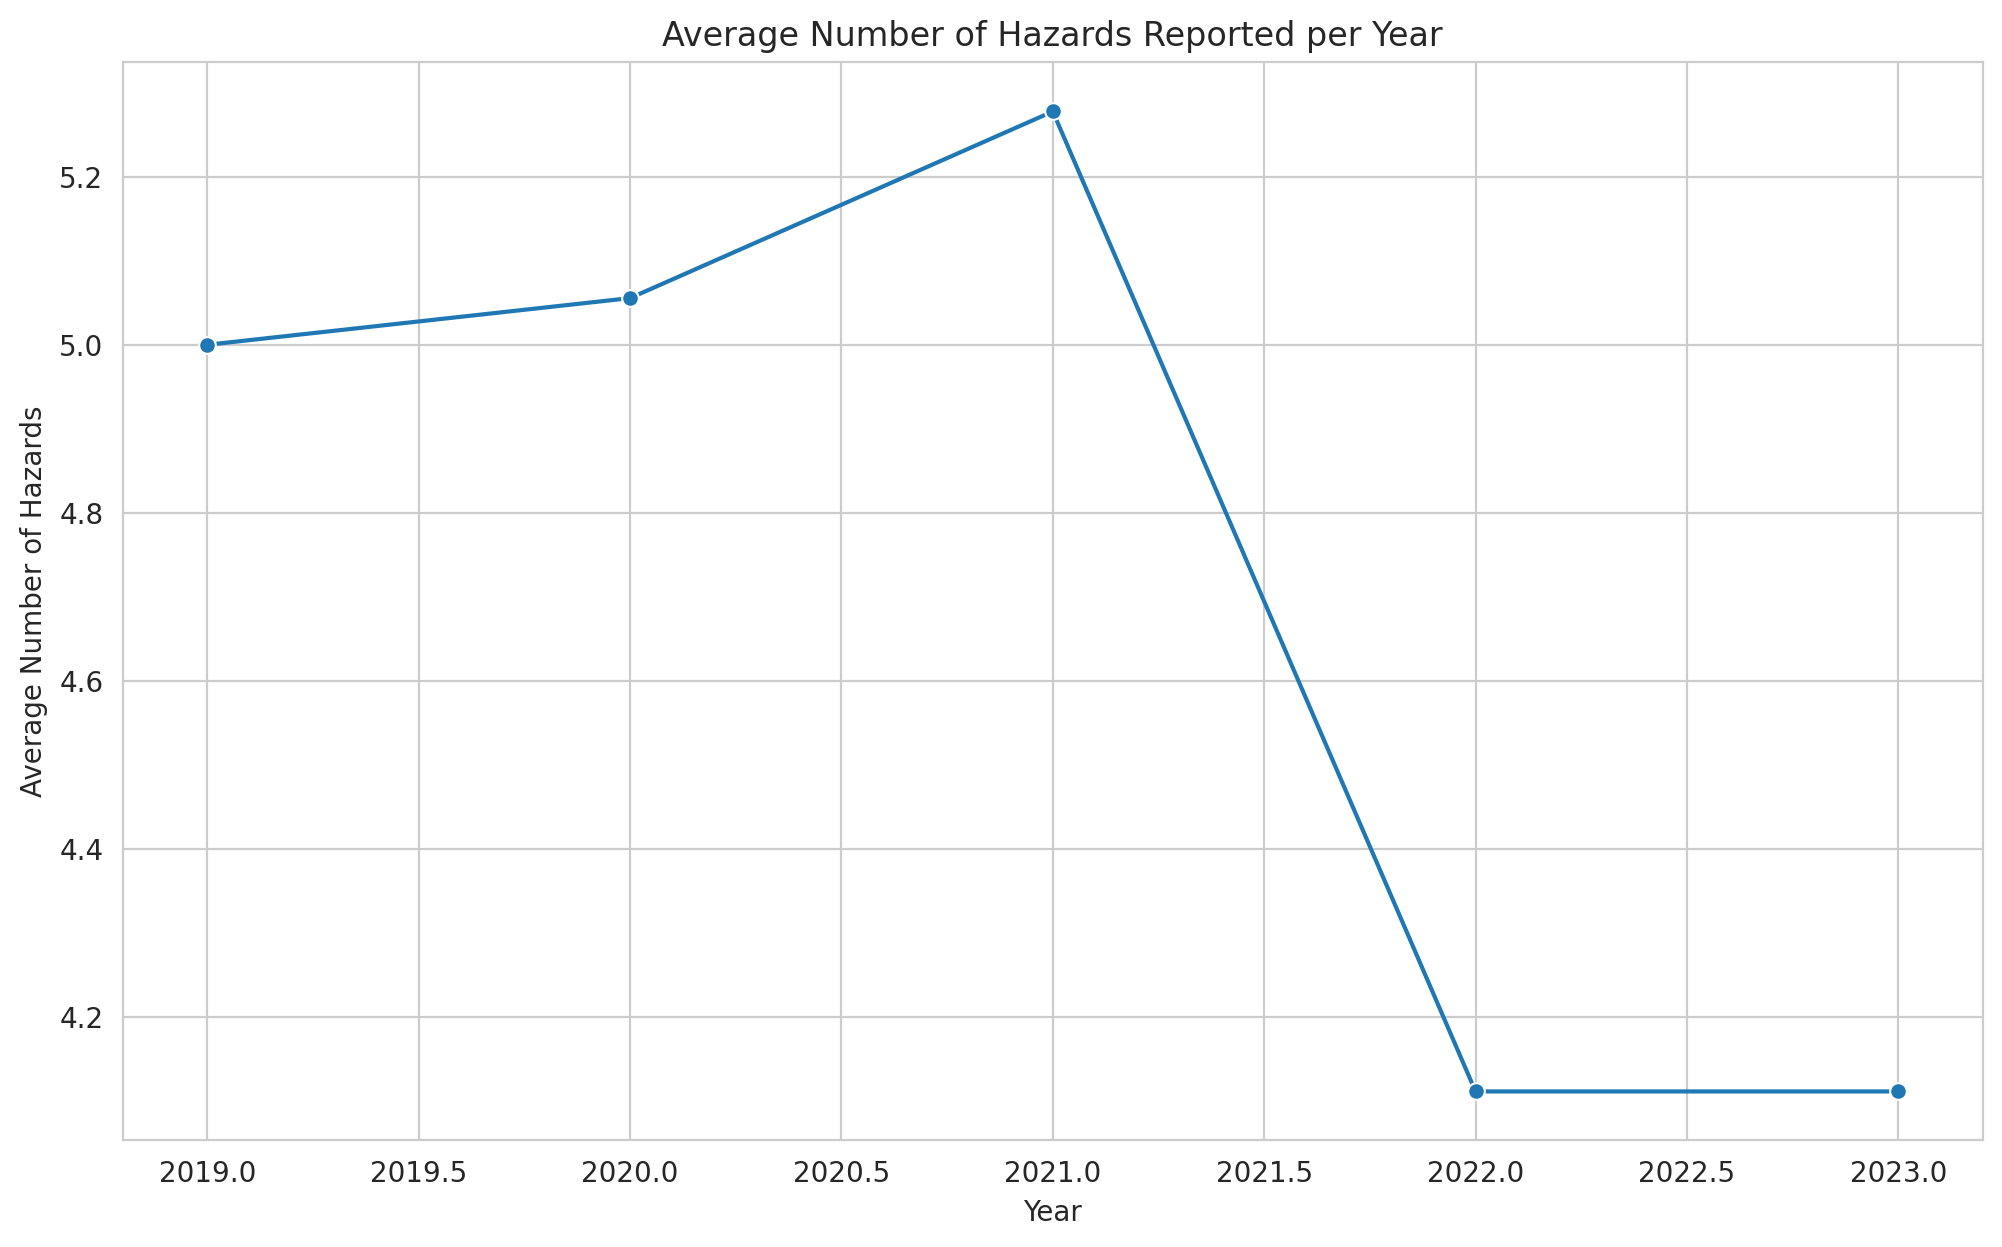

In [72]:
# Average hazards per year
avg_hazards_year = df.groupby('CDP_response_year')['num_hazards'].mean().reset_index()
sns.lineplot(data=avg_hazards_year, x='CDP_response_year', y='num_hazards', marker='o')
plt.title("Average Number of Hazards Reported per Year")
plt.ylabel("Average Number of Hazards")
plt.xlabel("Year")
plt.show()

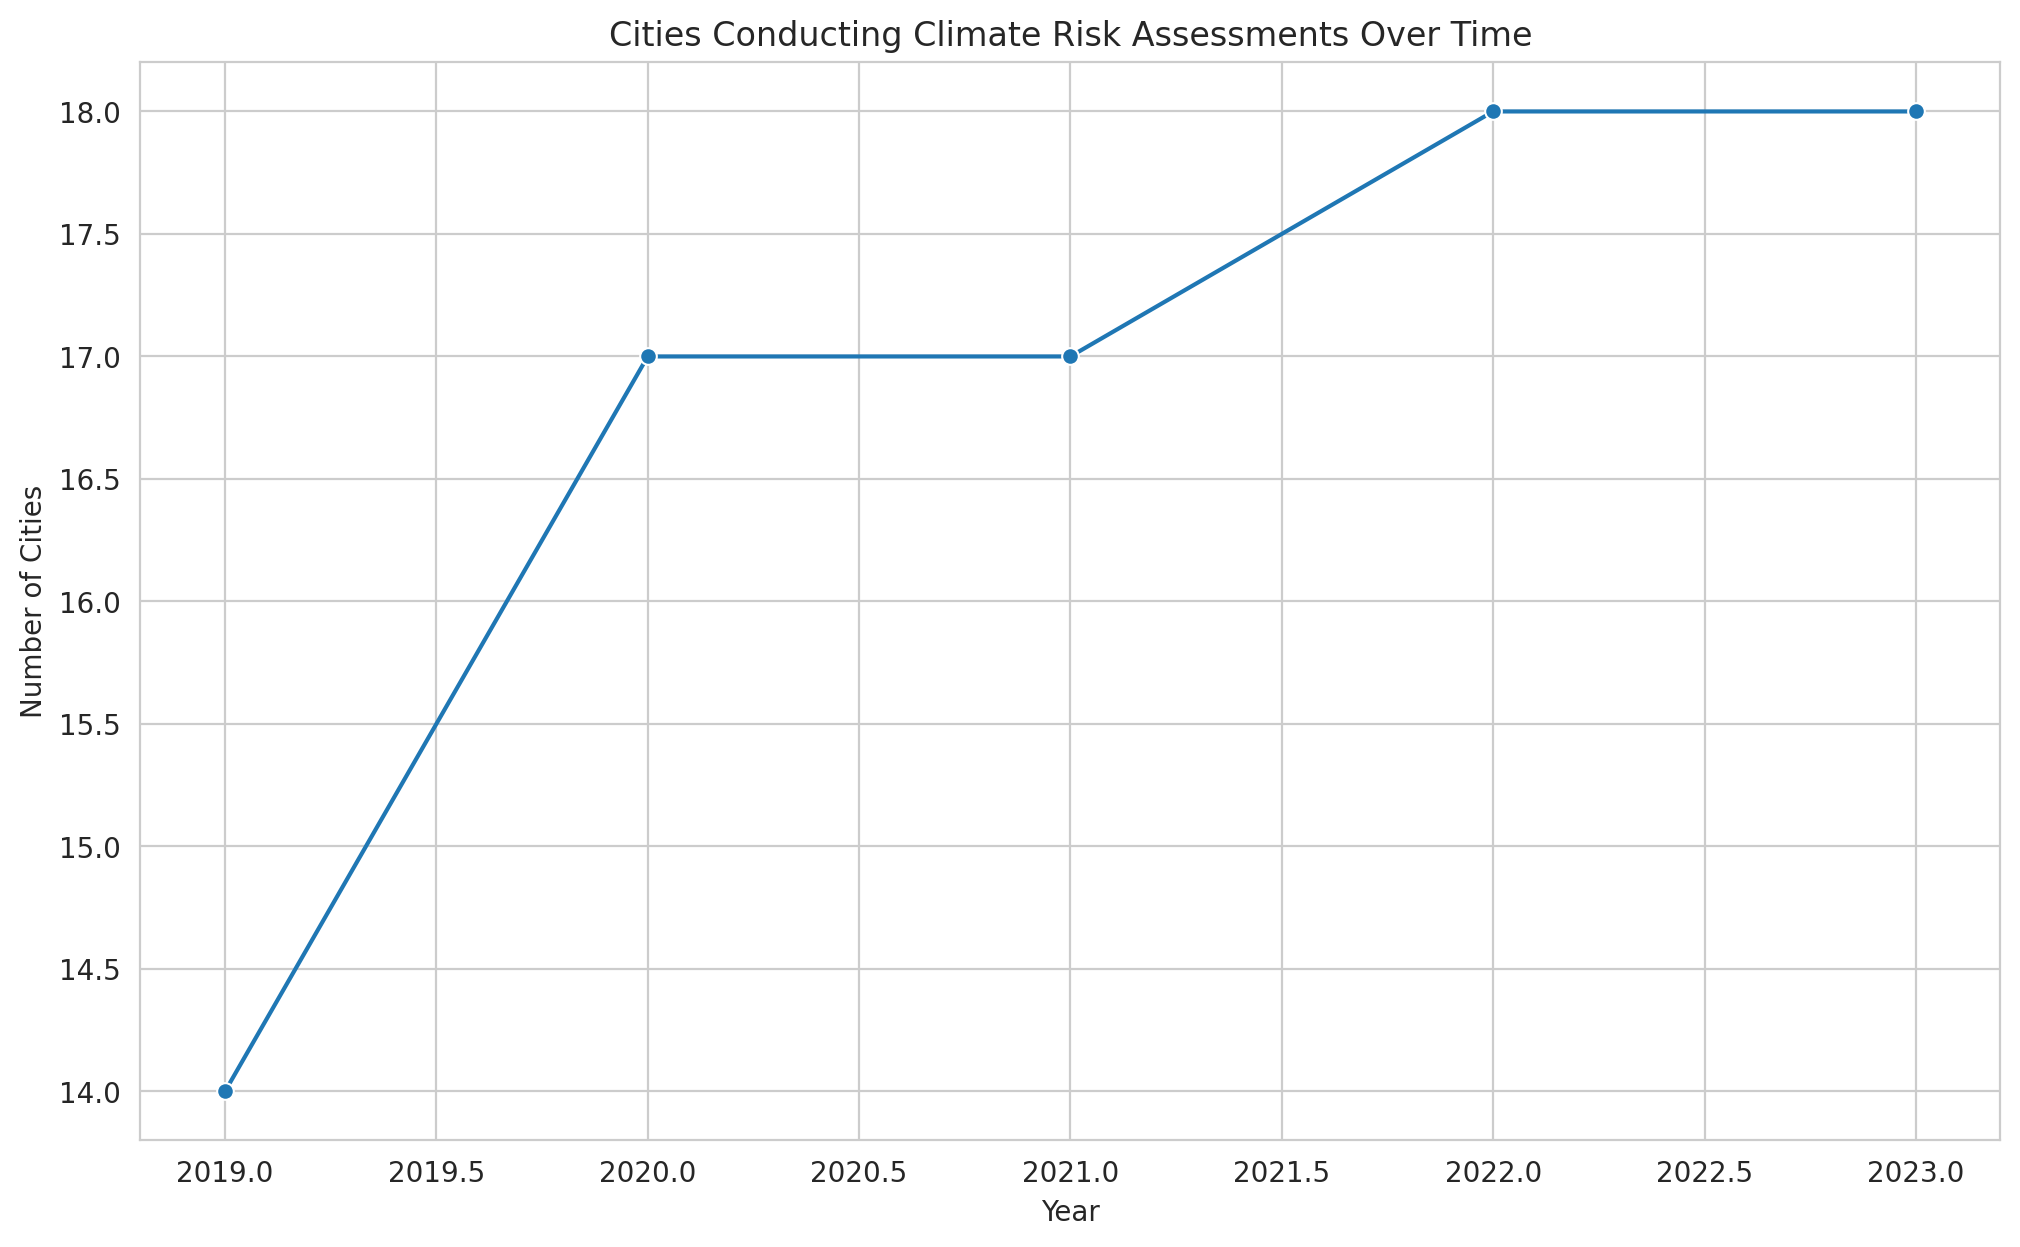

In [73]:
# Cities doing assessments over time
sns.lineplot(data=cities_per_year, x='CDP_response_year', y='num_cities_doing_assessment', marker='o')
plt.title("Cities Conducting Climate Risk Assessments Over Time")
plt.ylabel("Number of Cities")
plt.xlabel("Year")
plt.show()

Insight: More cities doing assessments over time, unclear on why hazards peaked and are now being reported less.



Hazard types by city characteristics:

Compare hazard types across: Population size \(small vs large\) and population density \(quartiles\)



/tmp/ipykernel_509/4112122217.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hazard_by_pop = df.groupby(['pop_quartile', 'most_common_hazard']).size().reset_index(name='count')


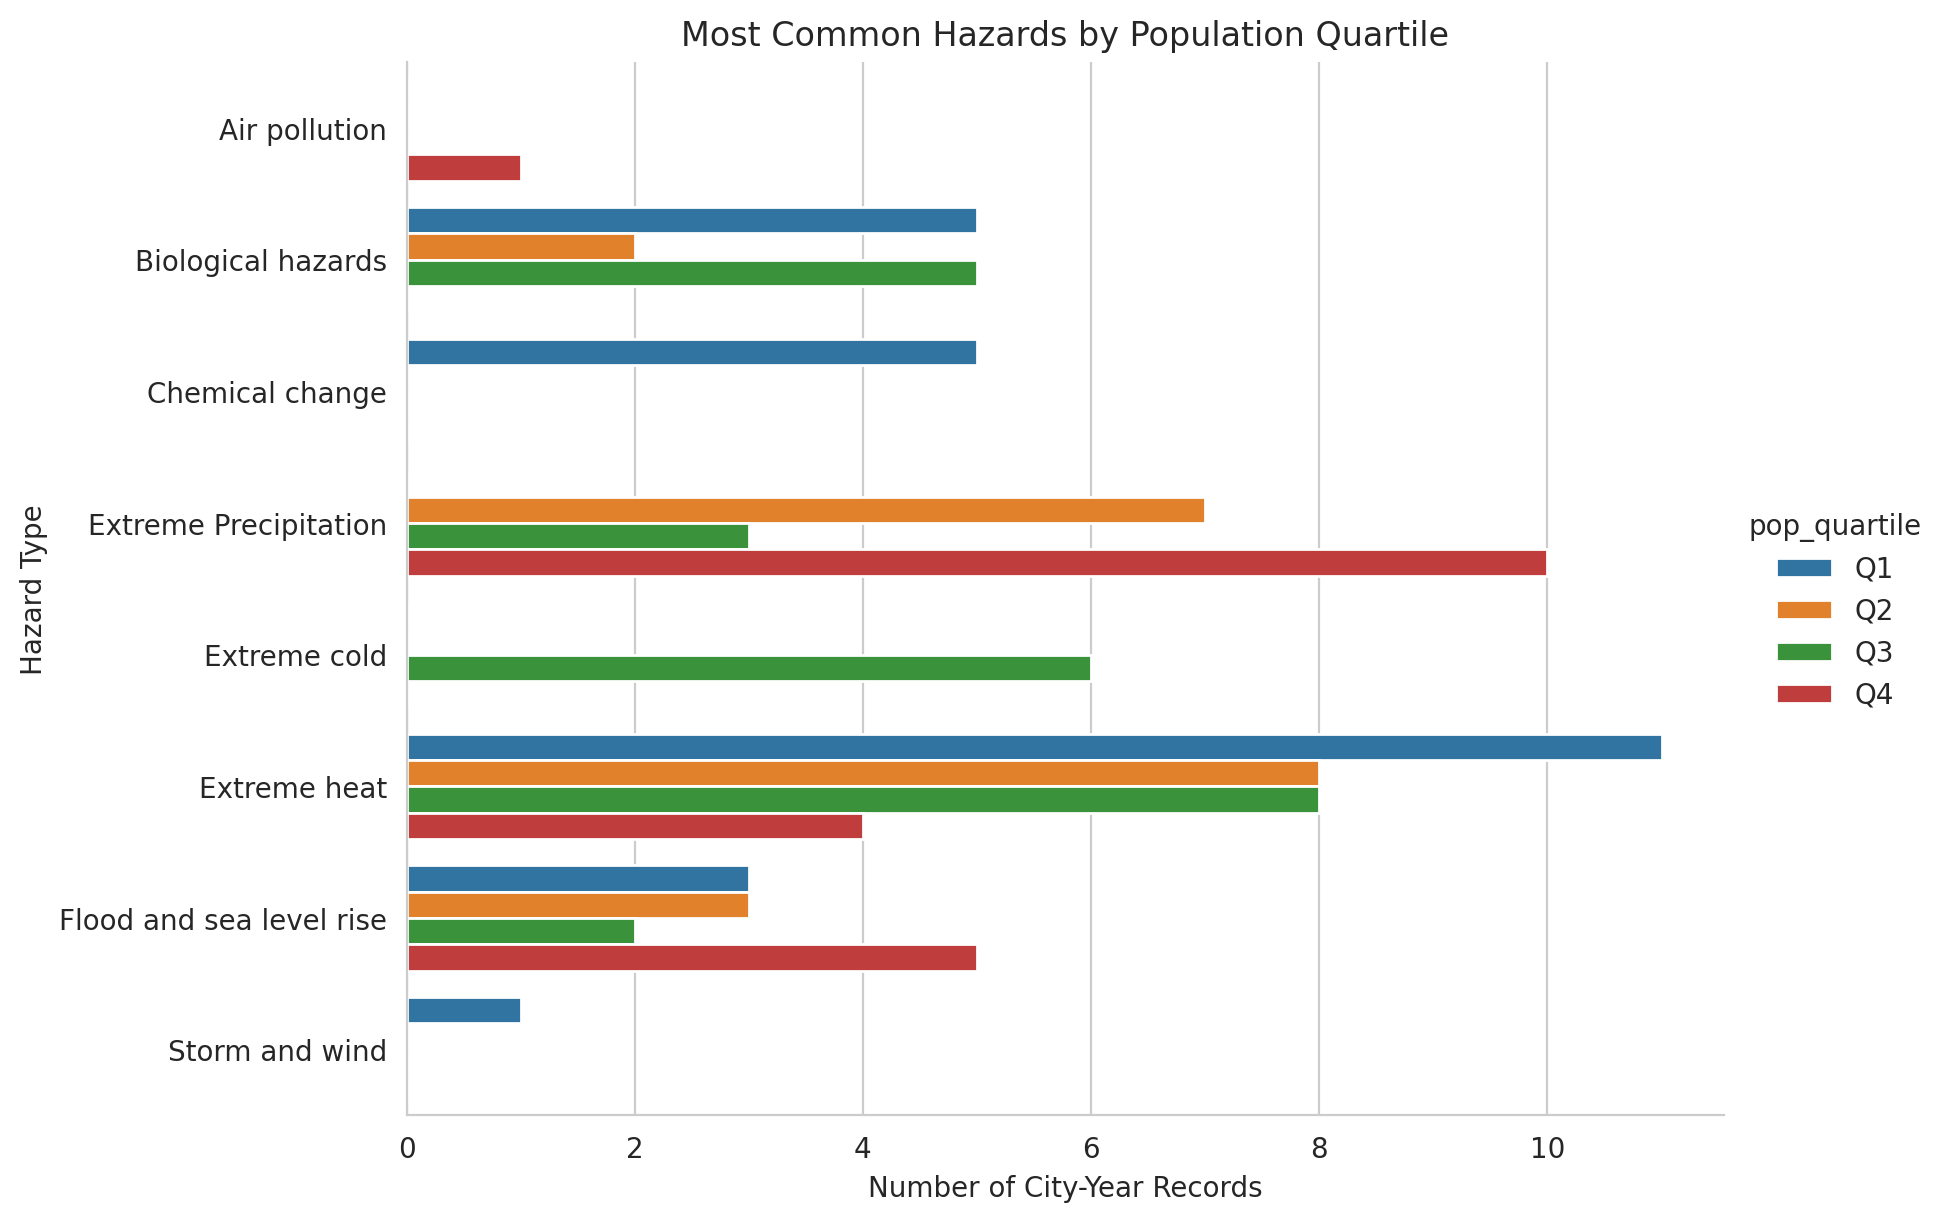

In [74]:
# Create population quartiles
df['pop_quartile'] = pd.qcut(df['population'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Count hazards by population quartile
hazard_by_pop = df.groupby(['pop_quartile', 'most_common_hazard']).size().reset_index(name='count')

sns.catplot(data=hazard_by_pop, x='count', y='most_common_hazard', hue='pop_quartile', kind='bar', height=6, aspect=1.5)
plt.title("Most Common Hazards by Population Quartile")
plt.xlabel("Number of City-Year Records")
plt.ylabel("Hazard Type")
plt.show()


Insight: ?



Correlation analysis



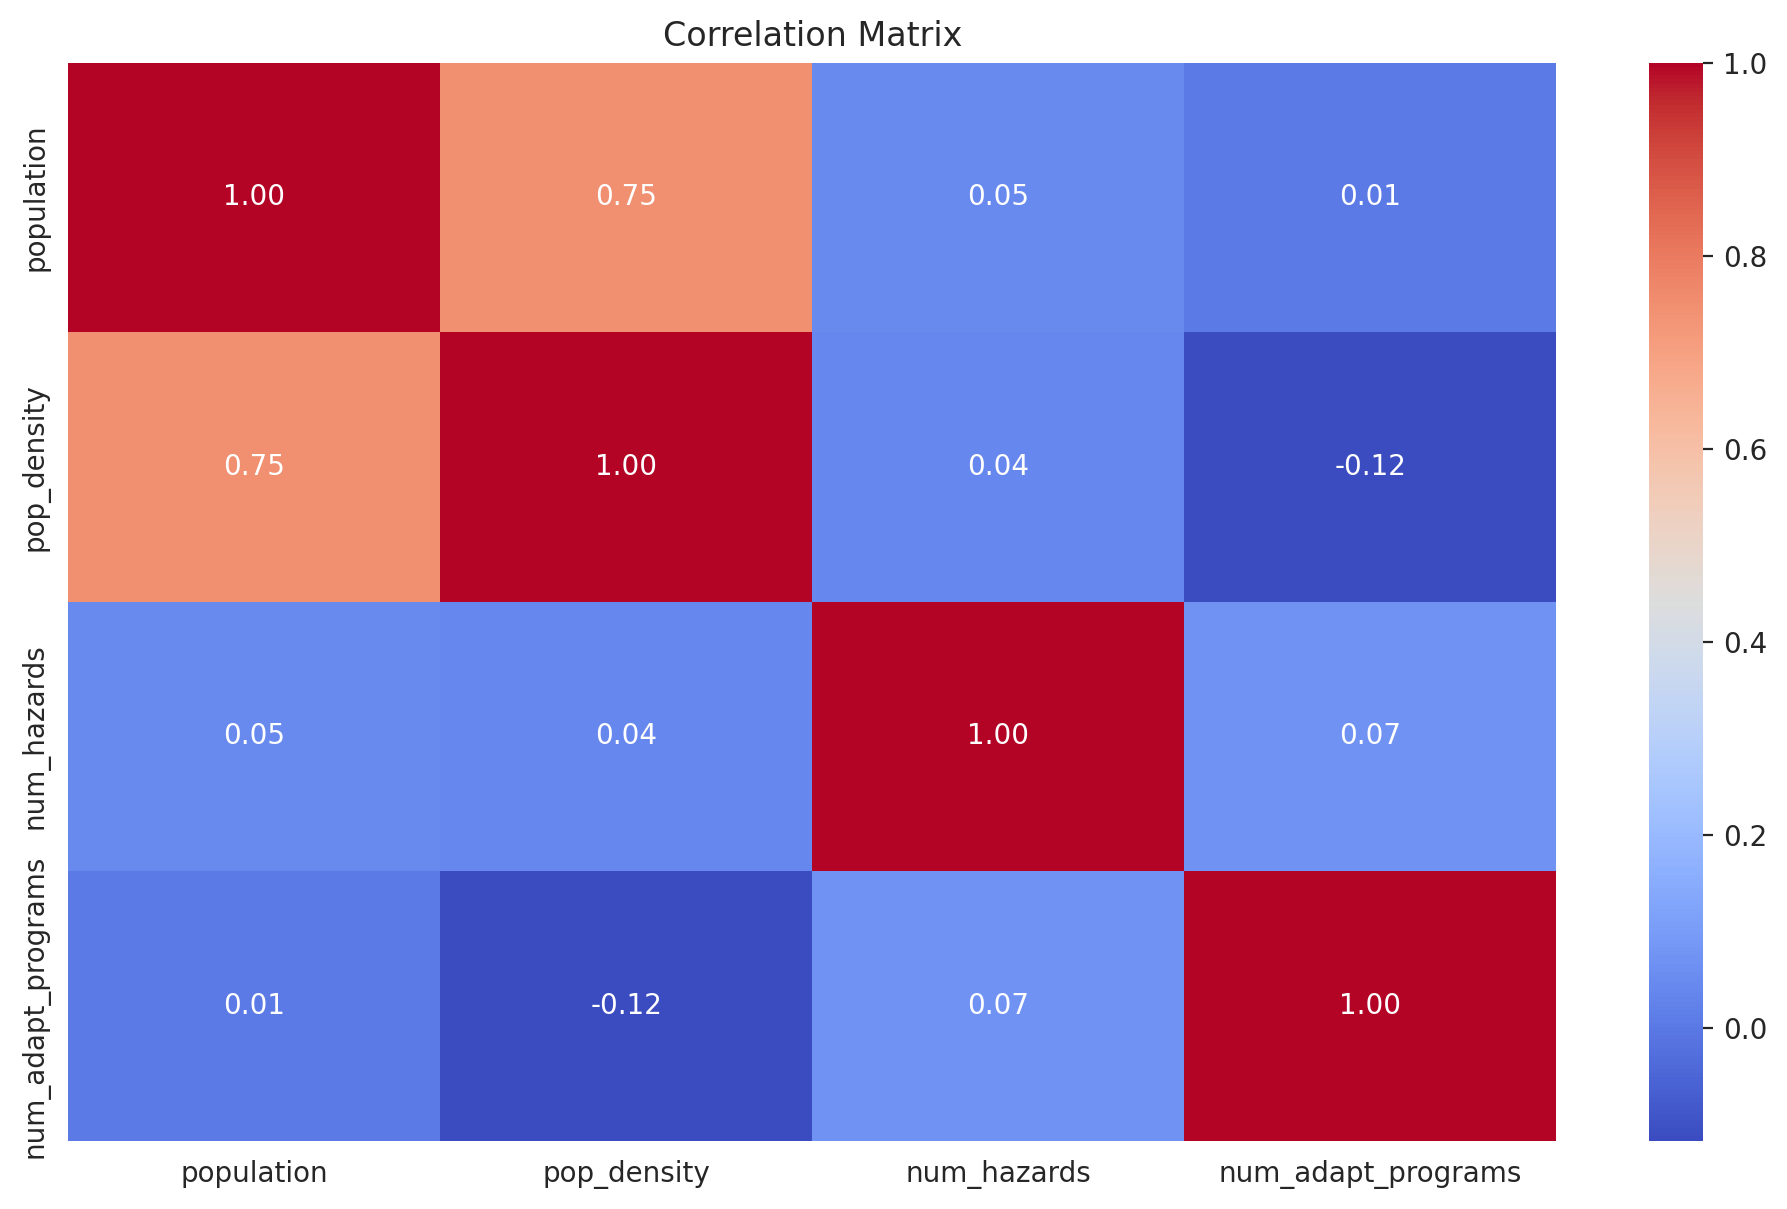

In [75]:
numeric_cols = ['population', 'pop_density', 'num_hazards', 'num_adapt_programs']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Insight: 


Analyzing potential COVID era impacts on climate risk assessments, hazards, and adaptation programs. 

Defining the COVID period:

- Pre\-COVID: 2019

- COVID\-impacted: 2020\-2021
- Post\-COVID normalization: 2022\-2023



In [76]:
df['covid_period'] = df['CDP_response_year'].apply(
    lambda x: 'Pre-COVID' if x <= 2019 else ('COVID-impacted' if x <= 2021 else 'Post-COVID')
)
df['covid_period'].value_counts()


covid_period
COVID-impacted    36
Post-COVID        36
Pre-COVID         18
Name: count, dtype: int64

/tmp/ipykernel_509/944980260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=covid_assess, x='covid_period', y='num_cities', palette='pastel')


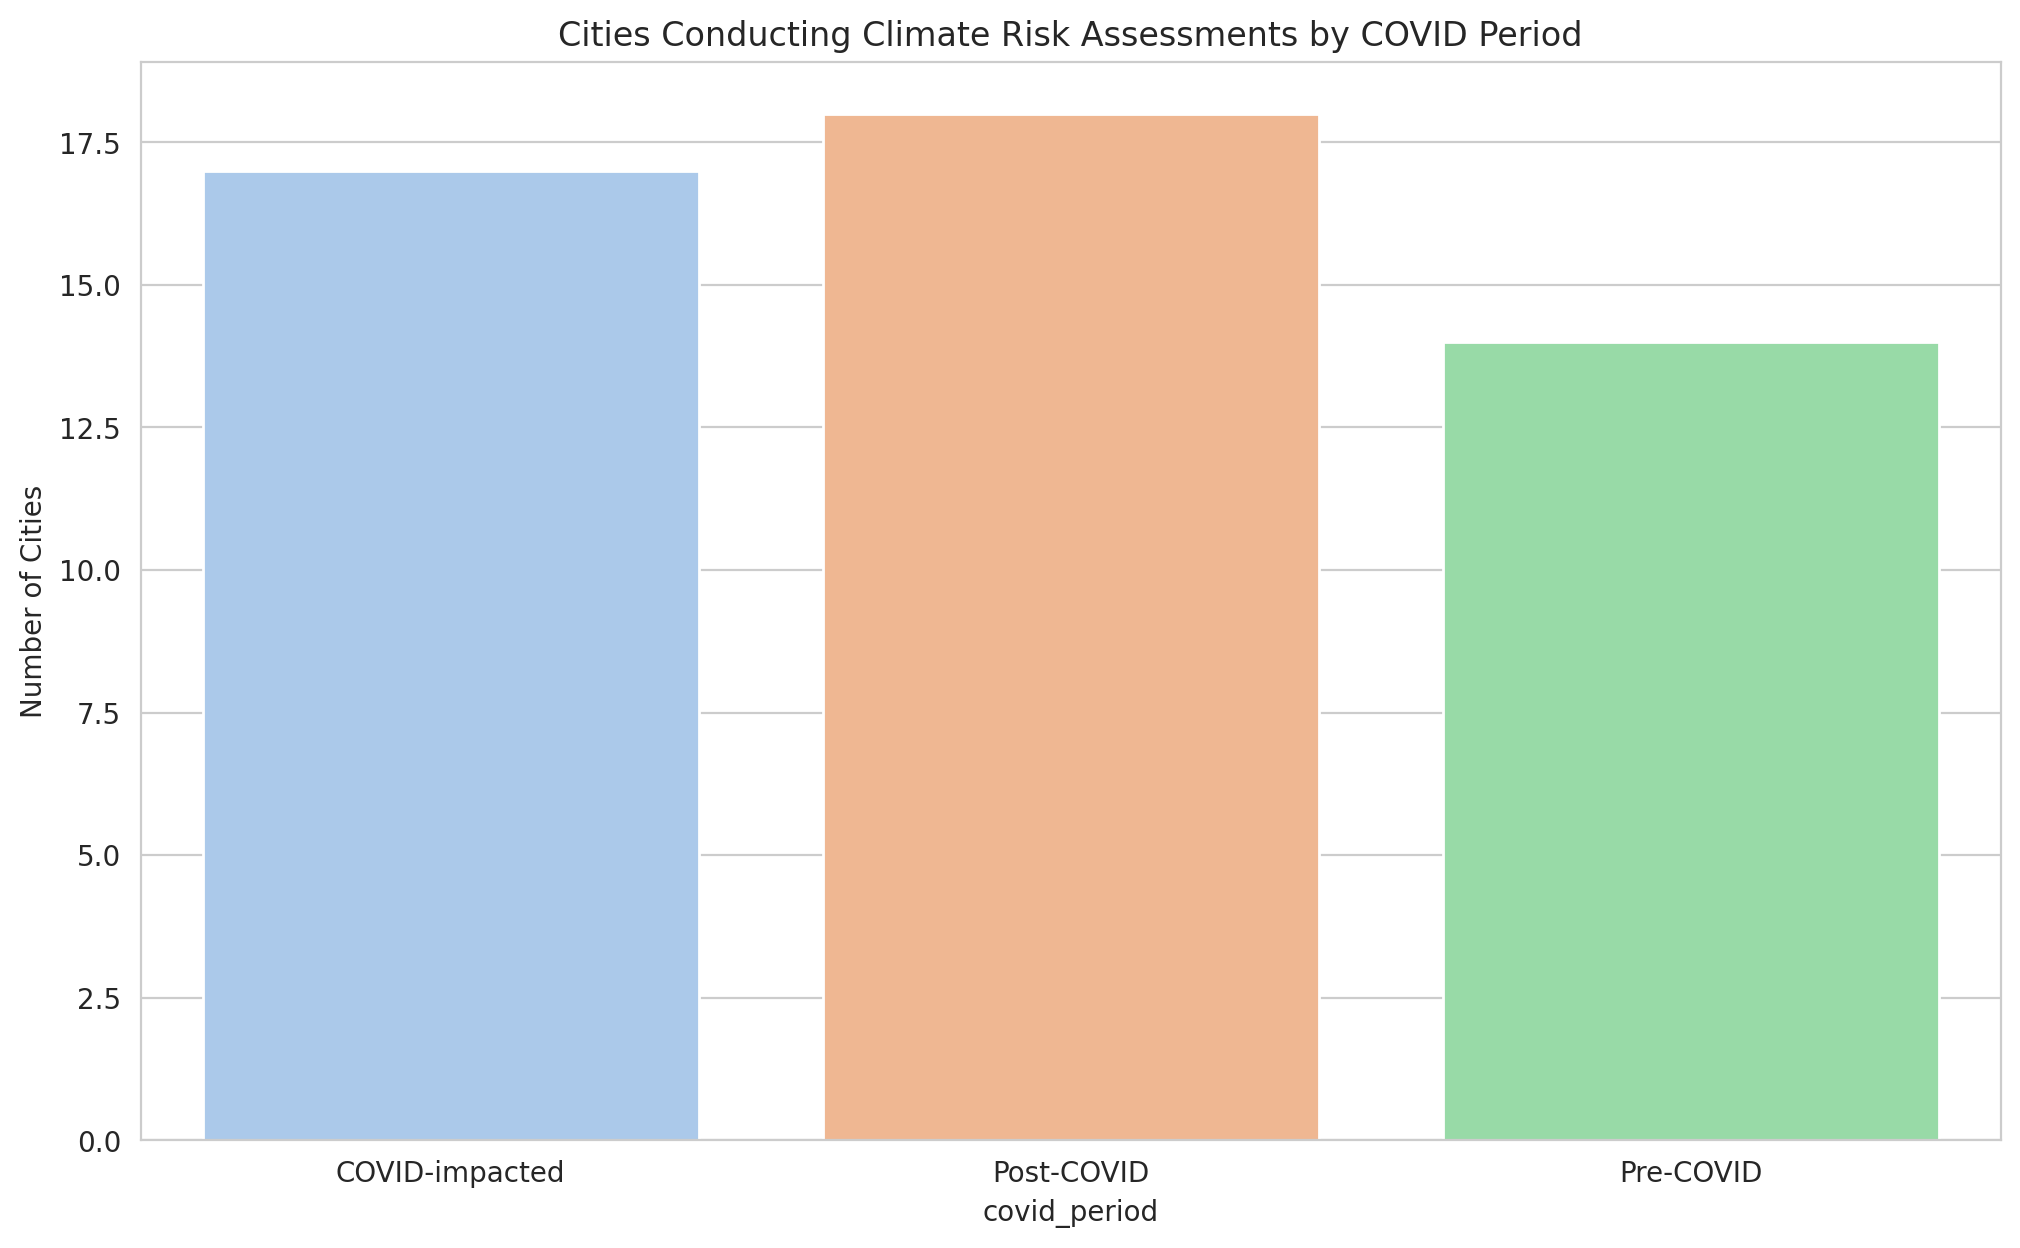

In [77]:
# Cities conducting assessments
covid_assess = df[df['climate_risk_assessment_YN']=='Yes'] \
    .groupby('covid_period')['city'].nunique().reset_index(name='num_cities')
sns.barplot(data=covid_assess, x='covid_period', y='num_cities', palette='pastel')
plt.title("Cities Conducting Climate Risk Assessments by COVID Period")
plt.ylabel("Number of Cities")
plt.show()


Insight: Less cities conducting assessments pre\-COVID, more during COVID, most post\-COVID.



/tmp/ipykernel_509/955713057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=covid_hazards, x='covid_period', y='num_hazards', palette='muted')


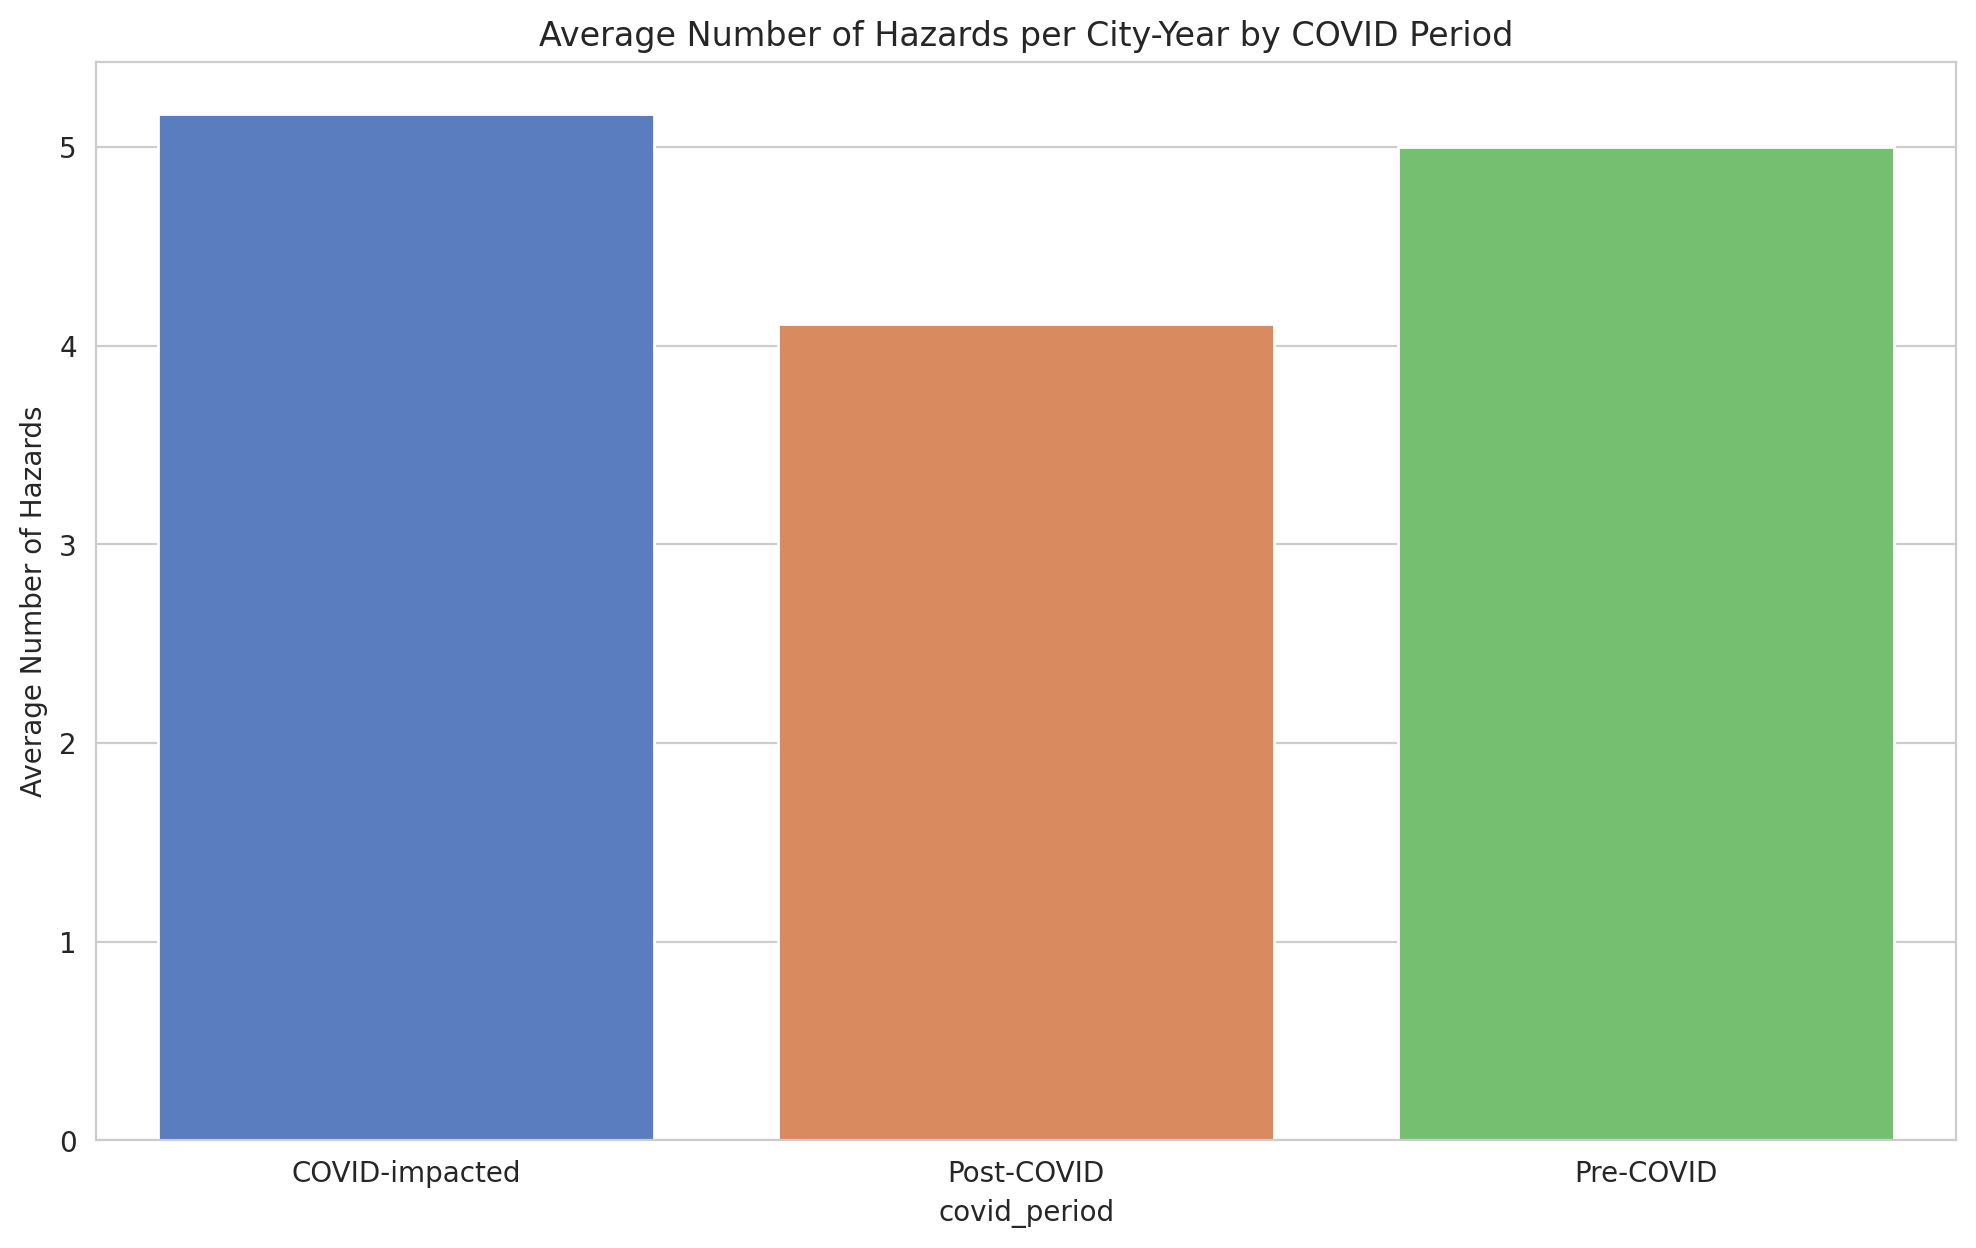

In [78]:
# Number of hazards reported
covid_hazards = df.groupby('covid_period')['num_hazards'].mean().reset_index()
sns.barplot(data=covid_hazards, x='covid_period', y='num_hazards', palette='muted')
plt.title("Average Number of Hazards per City-Year by COVID Period")
plt.ylabel("Average Number of Hazards")
plt.show()


Insight: Number of hazards reported during COVID were the highest, pre\-COVID were the second highest and post\-COVID were the lowest.



/tmp/ipykernel_509/3006710280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=covid_adapt, x='covid_period', y='num_adapt_programs', palette='cool')


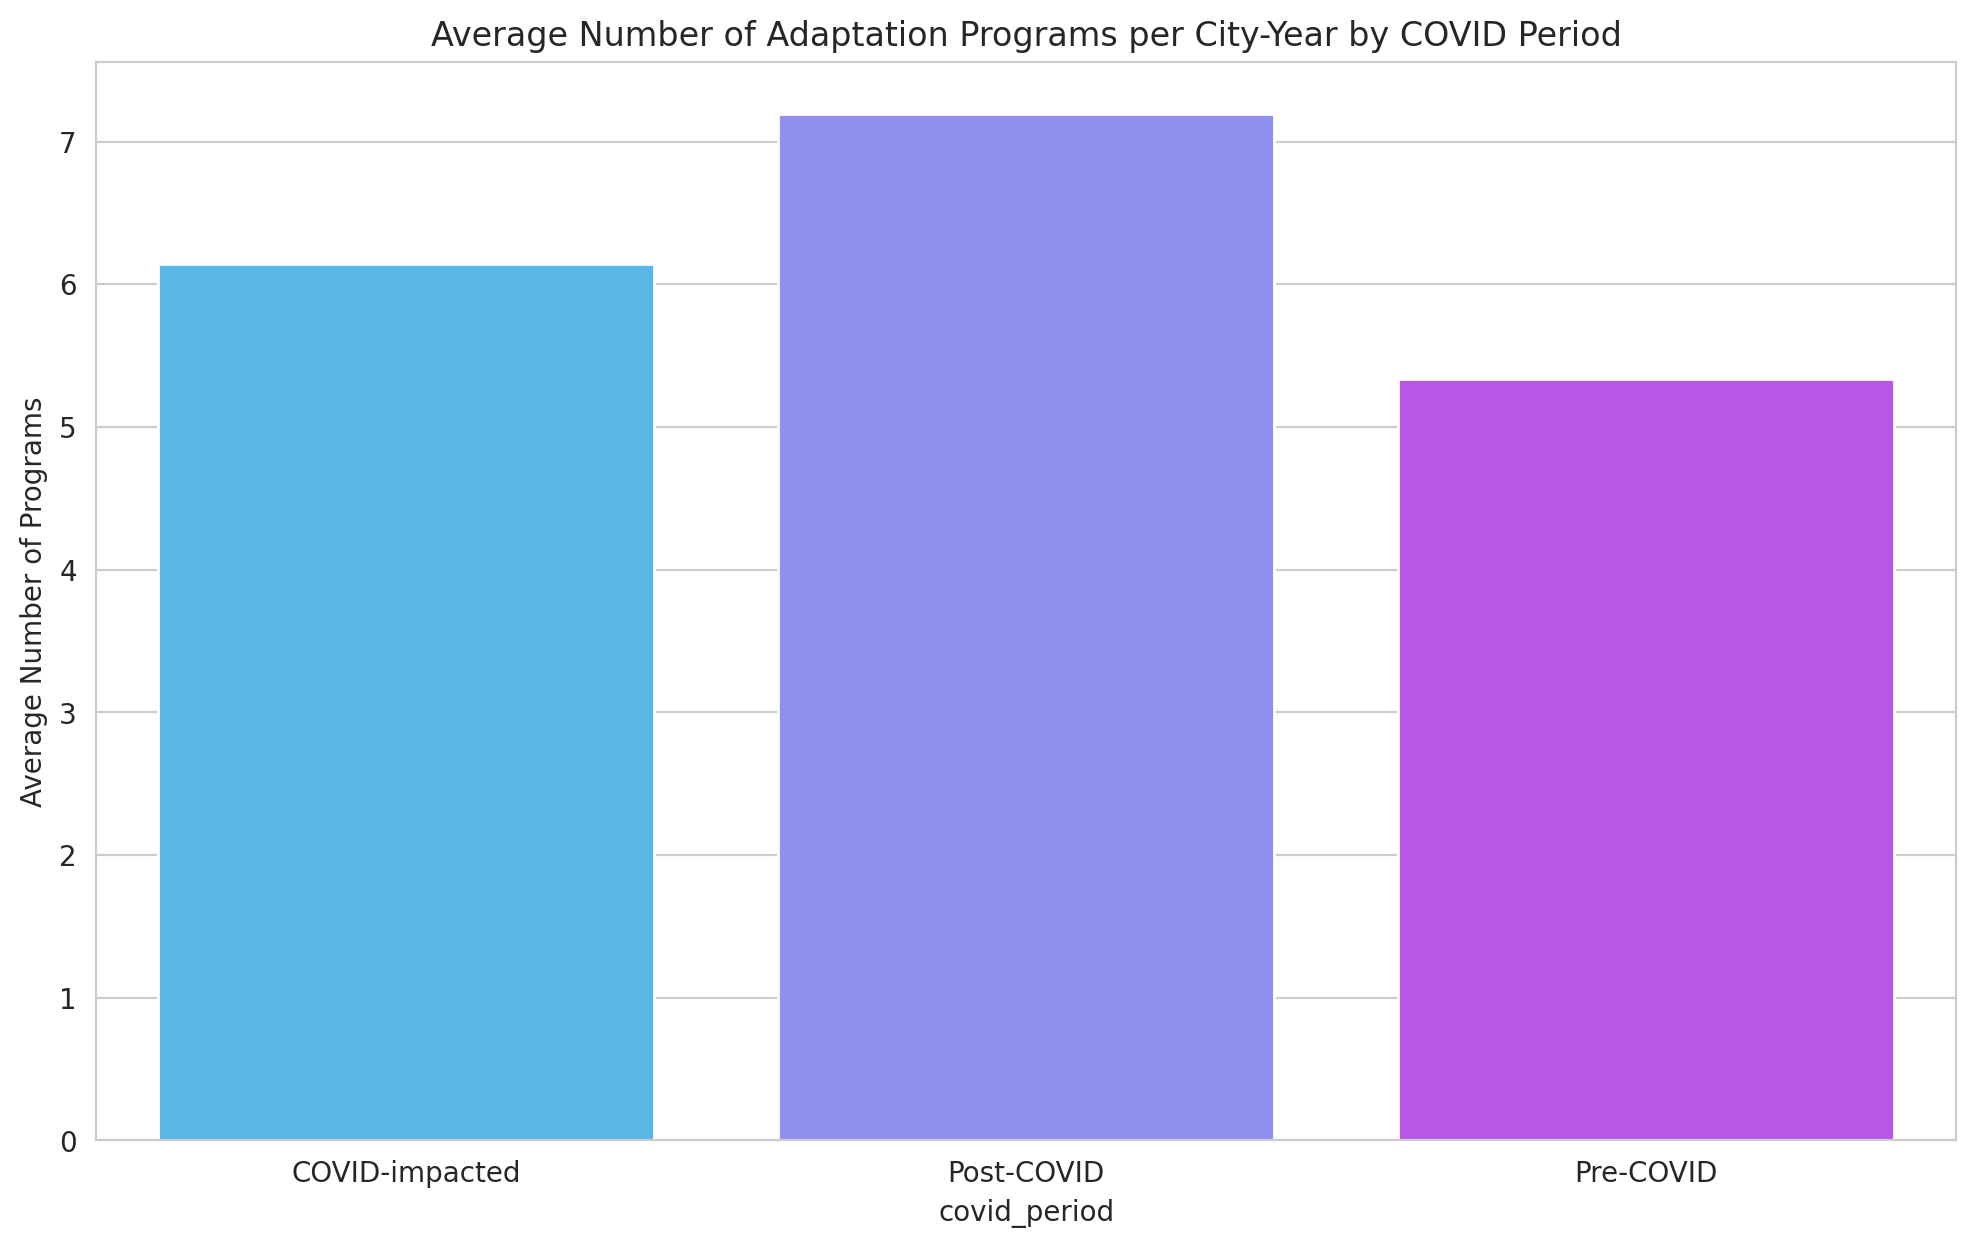

In [79]:
# Number of adaptation programs
covid_adapt = df.groupby('covid_period')['num_adapt_programs'].mean().reset_index()
sns.barplot(data=covid_adapt, x='covid_period', y='num_adapt_programs', palette='cool')
plt.title("Average Number of Adaptation Programs per City-Year by COVID Period")
plt.ylabel("Average Number of Programs")
plt.show()


Insights: Number of adaptation programs reported was the lowest pre\-COVID, middle during COVID, and highest post\-COVID.



In [3]:
df.to_csv("capstone_city_climate_data.csv", index=False)


NameError: name 'df' is not defined

In [4]:
import os
os.listdir()


['2023_land_area.csv',
 '2021_adaptation.csv',
 '2023_assessment.csv',
 '2020_population.csv',
 '2021_assessment.csv',
 '2023_hazards.csv',
 '2023_adaptation.csv',
 'cdp_capstone_analysis.ipynb',
 '2021_hazards.csv',
 '2022_population.csv',
 '.cdp_capstone_analysis.ipynb.sage-chat',
 '2019_population.csv',
 '2023_population.csv',
 '2022_hazards.csv',
 '2020_assessment.csv',
 '2019_adaptation.csv',
 '.cdp_capstone_analysis.ipynb.sage-jupyter2',
 '2020_hazards.csv',
 '2022_adaptation.csv',
 '2019_hazards.csv',
 '2021_population.csv',
 '2019_assessment.csv',
 '2020_adaptation.csv',
 '2022_assessment.csv']